# Spectral Diffusion Stock Clustering




## Revision notes

This revised notebook extends the original clustering workflow into a fuller diffusion-based comparison pipeline:

- Build a self-tuning kNN affinity graph from `X_scaled`, then compute alpha-normalized diffusion maps with `alpha in {0.0, 0.5, 1.0}` and tune `diffusion_t` on a compact search grid.
- Compare multiple diffusion-aware variants: spectral clustering on the original graph, `KMeans` on diffusion coordinates, and optional spectral re-affinity after rebuilding the kNN graph in diffusion space.
- Evaluate every label set in both spaces, `X` and diffusion space, so the notebook shows whether a method separates better in the original Euclidean feature space or in the latent manifold representation.
- In the final execution block, show the tuning table first, then lock a presentation-friendly demo config so the final clusters are easier to explain in Colab while still reporting all metrics honestly.


## Environment and Data Path

This section imports base libraries and resolves `price_train.csv` from kaggle:



In [53]:
import gdown
import os
os.makedirs("data", exist_ok=True)
gdown.download("https://drive.google.com/file/d/1b6MbsEHj6K6M5JojQ_rPV8PdoSi4NYt5/view?usp=sharing", "data/price_train.csv", quiet=False, fuzzy=True)

Downloading...
From: https://drive.google.com/uc?id=1b6MbsEHj6K6M5JojQ_rPV8PdoSi4NYt5
To: d:\Workspace\python\data\price_train.csv
100%|██████████| 273k/273k [00:00<00:00, 2.08MB/s]


'data/price_train.csv'

In [54]:
# =========================
# Load & standardize raw OHLCV data
# =========================

import pandas as pd
import numpy as np
from pathlib import Path

# Priority 1: local file in current workspace
local_candidates = [
    Path("price_train.csv"),
    Path("./data/price_train.csv"),
]

DATA_PATH = None
for p in local_candidates:
    if p.exists():
        DATA_PATH = str(p.resolve())
        break

# Priority 2: Colab Drive fallback
if DATA_PATH is None:
    try:
        from google.colab import drive  # type: ignore

        drive.mount("/content/drive")
        colab_path = Path("/content/drive/MyDrive/DataMining/price_train.csv")
        if colab_path.exists():
            DATA_PATH = str(colab_path)
    except Exception:
        DATA_PATH = None

if DATA_PATH is None:
    raise FileNotFoundError(
        "Cannot find price_train.csv. Put file in current folder or set a valid Colab path."
    )

print("Using DATA_PATH:", DATA_PATH)


Using DATA_PATH: D:\Workspace\python\data\price_train.csv


## Schema Standardization and Raw Data Loading

The loader normalizes input columns into this canonical schema:
`date, symbol, open, high, low, close, volume`.

It also:
- parses dates,
- casts numeric columns,
- trims and uppercases symbols,
- sorts by `(symbol, date)` for time-series consistency.


In [55]:
def standardize_stock_columns(df: pd.DataFrame) -> pd.DataFrame:
    """
    Chuan hoa ten cot ve bo:
    date, symbol, open, high, low, close, volume
    """
    df = df.copy()
    df.columns = [c.strip().lower() for c in df.columns]

    rename_map = {
        "ticker": "symbol",
        "stock": "symbol",
        "code": "symbol",
        "ma": "symbol",
        "datetime": "date",
        "time": "date",
        "vol": "volume",
        "trading_volume": "volume",
        "adj close": "close",
        "adjusted_close": "close",
    }

    df = df.rename(columns=rename_map)

    required_cols = ["date", "symbol", "open", "high", "low", "close", "volume"]
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise ValueError(f"Thieu cot bat buoc: {missing}")

    return df[required_cols].copy()


def _raise_if_html_payload(path: str) -> None:
    preview = Path(path).read_text(encoding="utf-8", errors="ignore")[:2048].lower()
    if "<html" in preview or "<!doctype html" in preview:
        raise ValueError(
            "price_train.csv hien dang la file HTML, khong phai CSV. "
            "Thuong la do tai file tu Google Drive bi loi / redirect. "
            "Hay thay bang file gia co cac cot date, symbol, open, high, low, close, volume."
        )


def load_price_data(path: str) -> pd.DataFrame:
    """
    Doc file CSV, chuan hoa cot, ep kieu du lieu co ban, sort theo symbol/date.
    """
    _raise_if_html_payload(path)

    try:
        df = pd.read_csv(path)
    except pd.errors.ParserError as exc:
        raise ValueError(
            "Khong doc duoc price_train.csv theo dinh dang CSV hop le. "
            "Kiem tra lai file input co dung la bang gia hay khong."
        ) from exc

    df = standardize_stock_columns(df)
    df["symbol"] = df["symbol"].astype(str).str.strip().str.upper()
    df["date"] = pd.to_datetime(df["date"], errors="coerce")

    numeric_cols = ["open", "high", "low", "close", "volume"]
    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    df = df.sort_values(["symbol", "date"]).reset_index(drop=True)
    return df


# Load data
raw_df = load_price_data(DATA_PATH)

print("Shape:", raw_df.shape)
print("Columns:", raw_df.columns.tolist())
print("Date range:", raw_df["date"].min(), "->", raw_df["date"].max())
print("Number of symbols:", raw_df["symbol"].nunique())
print("\nSample:")
display(raw_df.head())

print("\nInfo:")
display(raw_df.dtypes)


Shape: (6149, 7)
Columns: ['date', 'symbol', 'open', 'high', 'low', 'close', 'volume']
Date range: 2021-01-04 00:00:00 -> 2021-10-29 00:00:00
Number of symbols: 30

Sample:


,date,symbol,open,high,low,close,volume
0,2021-01-04,BID,47.75,48.45,47.75,48.25,1993800
1,2021-01-05,BID,47.90,48.10,47.65,47.90,2155700
2,2021-01-06,BID,48.30,50.60,47.55,48.80,3674500
3,2021-01-07,BID,48.80,49.90,48.50,48.90,1781500
4,2021-01-08,BID,49.30,49.30,48.20,48.50,2034900



Info:


date      datetime64[us]
symbol               str
open             float64
high             float64
low              float64
close            float64
volume             int64
dtype: object

## Data Cleaning Logic

Cleaning enforces market-data validity:
- remove missing key fields,
- remove duplicate `(symbol, date)` rows,
- enforce price positivity,
- enforce OHLC logical consistency (`high` and `low` bounds),
- keep symbols with enough history length.

This reduces noisy rows before feature generation.


In [56]:
# =========================
# Clean OHLCV data
# =========================

def clean_price_data(
    df: pd.DataFrame,
    min_history_ratio: float = 0.8,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Làm sạch dữ liệu OHLCV:
    1) Bỏ date/symbol null
    2) Bỏ duplicate theo (symbol, date)
    3) Bỏ các dòng thiếu OHLCV
    4) Bỏ các dòng có giá <= 0, volume < 0
    5) Giữ lại các mã có đủ lịch sử giao dịch

    Parameters
    ----------
    df : DataFrame
        Data gốc đã chuẩn hóa từ bước 1
    min_history_ratio : float
        Giữ lại các mã có số phiên >= ratio * số phiên lớn nhất

    Returns
    -------
    clean_df : DataFrame
        Data đã làm sạch
    symbol_stats : DataFrame
        Thống kê số phiên theo từng mã sau cleaning
    """
    data = df.copy()

    print("=== BEFORE CLEANING ===")
    print("Shape:", data.shape)
    print("Symbols:", data["symbol"].nunique())
    print("Date range:", data["date"].min(), "->", data["date"].max())

    # 1) Bỏ thiếu symbol/date
    data = data.dropna(subset=["date", "symbol"])

    # 2) Bỏ duplicate theo (symbol, date), giữ dòng cuối
    before_dup = len(data)
    data = data.drop_duplicates(subset=["symbol", "date"], keep="last")
    removed_dup = before_dup - len(data)

    # 3) Bỏ dòng thiếu OHLCV quan trọng
    required_numeric = ["open", "high", "low", "close", "volume"]
    before_na = len(data)
    data = data.dropna(subset=required_numeric)
    removed_na = before_na - len(data)

    # 4) Bỏ dữ liệu giá / volume không hợp lệ
    before_invalid = len(data)

    price_valid = (
        (data["open"] > 0) &
        (data["high"] > 0) &
        (data["low"] > 0) &
        (data["close"] > 0)
    )
    volume_valid = data["volume"] >= 0

    # high phải >= open/close/low, low phải <= open/close/high
    ohlc_valid = (
        (data["high"] >= data[["open", "close", "low"]].max(axis=1)) &
        (data["low"] <= data[["open", "close", "high"]].min(axis=1))
    )

    data = data[price_valid & volume_valid & ohlc_valid].copy()
    removed_invalid = before_invalid - len(data)

    # sort lại cho chắc
    data = data.sort_values(["symbol", "date"]).reset_index(drop=True)

    # 5) Giữ lại các mã có đủ số phiên
    symbol_counts = (
        data.groupby("symbol")
        .size()
        .rename("n_obs")
        .sort_values(ascending=False)
    )

    max_obs = int(symbol_counts.max())
    min_required = int(np.floor(max_obs * min_history_ratio))

    valid_symbols = symbol_counts[symbol_counts >= min_required].index.tolist()

    before_filter_symbols = data["symbol"].nunique()
    data = data[data["symbol"].isin(valid_symbols)].copy()
    after_filter_symbols = data["symbol"].nunique()

    # thống kê cuối
    symbol_stats = (
        data.groupby("symbol")
        .agg(
            n_obs=("date", "size"),
            start_date=("date", "min"),
            end_date=("date", "max"),
        )
        .sort_values(["n_obs", "symbol"], ascending=[False, True])
        .reset_index()
    )

    print("\n=== CLEANING SUMMARY ===")
    print("Removed duplicates:", removed_dup)
    print("Removed missing rows:", removed_na)
    print("Removed invalid OHLCV rows:", removed_invalid)
    print("Max observations among symbols:", max_obs)
    print("Min required observations:", min_required)
    print("Symbols before history filter:", before_filter_symbols)
    print("Symbols after history filter:", after_filter_symbols)

    print("\n=== AFTER CLEANING ===")
    print("Shape:", data.shape)
    print("Symbols:", data["symbol"].nunique())
    print("Date range:", data["date"].min(), "->", data["date"].max())

    return data.reset_index(drop=True), symbol_stats



clean_df, symbol_stats = clean_price_data(raw_df, min_history_ratio=0.8)

print("\nPreview clean_df:")
display(clean_df.head())

print("\nSymbol stats:")
display(symbol_stats.head(10))


=== BEFORE CLEANING ===
Shape: (6149, 7)
Symbols: 30
Date range: 2021-01-04 00:00:00 -> 2021-10-29 00:00:00

=== CLEANING SUMMARY ===
Removed duplicates: 0
Removed missing rows: 0
Removed invalid OHLCV rows: 1
Max observations among symbols: 205
Min required observations: 164
Symbols before history filter: 30
Symbols after history filter: 30

=== AFTER CLEANING ===
Shape: (6148, 7)
Symbols: 30
Date range: 2021-01-04 00:00:00 -> 2021-10-29 00:00:00

Preview clean_df:


,date,symbol,open,high,low,close,volume
0,2021-01-04,BID,47.75,48.45,47.75,48.25,1993800
1,2021-01-05,BID,47.90,48.10,47.65,47.90,2155700
2,2021-01-06,BID,48.30,50.60,47.55,48.80,3674500
3,2021-01-07,BID,48.80,49.90,48.50,48.90,1781500
4,2021-01-08,BID,49.30,49.30,48.20,48.50,2034900



Symbol stats:


,symbol,n_obs,start_date,end_date
0,BID,205,2021-01-04,2021-10-29
1,BVH,205,2021-01-04,2021-10-29
2,CTG,205,2021-01-04,2021-10-29
3,FPT,205,2021-01-04,2021-10-29
4,GAS,205,2021-01-04,2021-10-29
5,HDB,205,2021-01-04,2021-10-29
6,HPG,205,2021-01-04,2021-10-29
7,KDH,205,2021-01-04,2021-10-29
8,MBB,205,2021-01-04,2021-10-29
9,MSN,205,2021-01-04,2021-10-29


## Panel Construction (Date x Symbol)

Wide matrices are built for downstream analytics:
- `close_wide` for price trajectories,
- `ret_wide` for simple returns,
- `logret_wide` for log returns,
- `norm_price_wide` for comparative charts (base-normalized series).


In [57]:
# =========================
# Build price panel and returns
# =========================

def build_price_panels(df: pd.DataFrame) -> dict:
    """
    Từ clean_df tạo ra các panel dạng wide:
    - close_wide: giá đóng cửa
    - volume_wide: khối lượng
    - ret_wide: simple return
    - logret_wide: log return
    - norm_price_wide: giá chuẩn hóa về 1 ở ngày đầu tiên có dữ liệu

    Returns
    -------
    panels : dict
        Dictionary chứa các DataFrame panel
    """
    data = df.copy()

    # Pivot sang dạng wide: index = date, columns = symbol
    close_wide = (
        data.pivot(index="date", columns="symbol", values="close")
        .sort_index()
        .sort_index(axis=1)
    )

    volume_wide = (
        data.pivot(index="date", columns="symbol", values="volume")
        .sort_index()
        .sort_index(axis=1)
    )

    # Simple return: P_t / P_{t-1} - 1
    ret_wide = close_wide.pct_change(fill_method=None)

    # Log return: ln(P_t / P_{t-1})
    logret_wide = np.log(close_wide / close_wide.shift(1))

    # Giá chuẩn hóa để vẽ: mỗi mã bắt đầu từ 1 ở ngày đầu tiên có dữ liệu
    norm_price_wide = close_wide.copy()
    for col in norm_price_wide.columns:
        first_valid_idx = norm_price_wide[col].first_valid_index()
        if first_valid_idx is not None:
            first_price = norm_price_wide.loc[first_valid_idx, col]
            if pd.notna(first_price) and first_price > 0:
                norm_price_wide[col] = norm_price_wide[col] / first_price

    panels = {
        "close_wide": close_wide,
        "volume_wide": volume_wide,
        "ret_wide": ret_wide,
        "logret_wide": logret_wide,
        "norm_price_wide": norm_price_wide,
    }
    return panels


def panel_quality_report(close_wide: pd.DataFrame, ret_wide: pd.DataFrame) -> pd.DataFrame:
    """
    Tạo báo cáo nhanh chất lượng panel theo từng mã.
    """
    report = pd.DataFrame({
        "n_price_obs": close_wide.notna().sum(),
        "n_return_obs": ret_wide.notna().sum(),
        "first_date": [close_wide[c].first_valid_index() for c in close_wide.columns],
        "last_date": [close_wide[c].last_valid_index() for c in close_wide.columns],
    }).sort_values(["n_price_obs", "n_return_obs"], ascending=False)

    return report.reset_index(names="symbol")



panels = build_price_panels(clean_df)

close_wide = panels["close_wide"]
volume_wide = panels["volume_wide"]
ret_wide = panels["ret_wide"]
logret_wide = panels["logret_wide"]
norm_price_wide = panels["norm_price_wide"]

panel_report = panel_quality_report(close_wide, ret_wide)

print("close_wide shape:", close_wide.shape)
print("ret_wide shape:", ret_wide.shape)
print("logret_wide shape:", logret_wide.shape)
print("norm_price_wide shape:", norm_price_wide.shape)

print("\nSample close_wide:")
display(close_wide.head())

print("\nSample ret_wide:")
display(ret_wide.head())

print("\nSample norm_price_wide:")
display(norm_price_wide.head())

print("\nPanel quality report:")
display(panel_report.head(10))


close_wide shape: (205, 30)
ret_wide shape: (205, 30)
logret_wide shape: (205, 30)
norm_price_wide shape: (205, 30)

Sample close_wide:


symbol,BID,BVH,CTG,FPT,GAS,HDB,HPG,KDH,MBB,MSN,...,TCB,TCH,TPB,VCB,VHM,VIC,VJC,VNM,VPB,VRE
date,,,,,,,,,,,,,,,,,,,,,
2021-01-04,48.25,66.3,35.50,60.2,88.8,24.10,42.30,29.35,23.95,88.9,...,33.00,20.05,27.80,99.0,92.0,108.0,125.8,109.3,34.20,31.65
2021-01-05,47.90,66.0,35.40,62.7,90.0,24.75,42.35,29.40,25.15,89.3,...,33.05,20.05,27.75,99.3,95.6,109.7,124.8,110.8,34.35,33.30
2021-01-06,48.80,66.5,37.85,62.4,90.4,25.65,42.80,30.00,25.30,88.3,...,33.20,20.80,28.00,105.0,94.8,110.2,123.7,109.8,34.40,33.20
2021-01-07,48.90,67.0,38.85,62.5,92.7,26.80,42.80,30.30,25.90,92.0,...,34.60,21.10,28.35,107.0,94.8,110.1,124.6,110.4,34.90,33.90
2021-01-08,48.50,68.3,38.70,63.3,92.7,27.10,42.75,30.50,26.60,93.1,...,35.70,22.55,28.50,104.8,96.4,111.8,126.5,112.0,35.55,35.50



Sample ret_wide:


symbol,BID,BVH,CTG,FPT,GAS,HDB,HPG,KDH,MBB,MSN,...,TCB,TCH,TPB,VCB,VHM,VIC,VJC,VNM,VPB,VRE
date,,,,,,,,,,,,,,,,,,,,,
2021-01-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-05,-0.007254,-0.004525,-0.002817,0.041528,0.013514,0.026971,0.001182,0.001704,0.050104,0.004499,...,0.001515,0.000000,-0.001799,0.003030,0.039130,0.015741,-0.007949,0.013724,0.004386,0.052133
2021-01-06,0.018789,0.007576,0.069209,-0.004785,0.004444,0.036364,0.010626,0.020408,0.005964,-0.011198,...,0.004539,0.037406,0.009009,0.057402,-0.008368,0.004558,-0.008814,-0.009025,0.001456,-0.003003
2021-01-07,0.002049,0.007519,0.026420,0.001603,0.025442,0.044834,0.000000,0.010000,0.023715,0.041903,...,0.042169,0.014423,0.012500,0.019048,0.000000,-0.000907,0.007276,0.005464,0.014535,0.021084
2021-01-08,-0.008180,0.019403,-0.003861,0.012800,0.000000,0.011194,-0.001168,0.006601,0.027027,0.011957,...,0.031792,0.068720,0.005291,-0.020561,0.016878,0.015441,0.015249,0.014493,0.018625,0.047198



Sample norm_price_wide:


symbol,BID,BVH,CTG,FPT,GAS,HDB,HPG,KDH,MBB,MSN,...,TCB,TCH,TPB,VCB,VHM,VIC,VJC,VNM,VPB,VRE
date,,,,,,,,,,,,,,,,,,,,,
2021-01-04,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
2021-01-05,0.992746,0.995475,0.997183,1.041528,1.013514,1.026971,1.001182,1.001704,1.050104,1.004499,...,1.001515,1.000000,0.998201,1.003030,1.039130,1.015741,0.992051,1.013724,1.004386,1.052133
2021-01-06,1.011399,1.003017,1.066197,1.036545,1.018018,1.064315,1.011820,1.022147,1.056367,0.993251,...,1.006061,1.037406,1.007194,1.060606,1.030435,1.020370,0.983307,1.004575,1.005848,1.048973
2021-01-07,1.013472,1.010558,1.094366,1.038206,1.043919,1.112033,1.011820,1.032368,1.081420,1.034871,...,1.048485,1.052369,1.019784,1.080808,1.030435,1.019444,0.990461,1.010064,1.020468,1.071090
2021-01-08,1.005181,1.030166,1.090141,1.051495,1.043919,1.124481,1.010638,1.039182,1.110647,1.047244,...,1.081818,1.124688,1.025180,1.058586,1.047826,1.035185,1.005564,1.024703,1.039474,1.121643



Panel quality report:


,symbol,n_price_obs,n_return_obs,first_date,last_date
0,BID,205,204,2021-01-04,2021-10-29
1,BVH,205,204,2021-01-04,2021-10-29
2,CTG,205,204,2021-01-04,2021-10-29
3,FPT,205,204,2021-01-04,2021-10-29
4,GAS,205,204,2021-01-04,2021-10-29
5,HDB,205,204,2021-01-04,2021-10-29
6,HPG,205,204,2021-01-04,2021-10-29
7,KDH,205,204,2021-01-04,2021-10-29
8,MBB,205,204,2021-01-04,2021-10-29
9,MSN,205,204,2021-01-04,2021-10-29


## Feature Engineering (Detailed Formula Notes)

For each stock, the notebook computes behavior descriptors:

- **Daily return**: $r_t = \frac{P_t}{P_{t-1}} - 1$
- **Volatility**: standard deviation of daily returns
- **Downside volatility**: standard deviation computed only on negative returns
- **Open-close return**: $\frac{C_t - O_t}{O_t}$
- **High-low range (previous-close scaled)**: $\frac{H_t - L_t}{P_{t-1}}$
- **Volume change volatility**: standard deviation of percentage changes in volume
- **Autocorr(1)**: lag-1 autocorrelation of daily returns
- **Momentum(20)**: $\frac{P_t}{P_{t-20}} - 1$
- **Max drawdown**: $\min_t\left(\frac{P_t}{\max_{s \le t} P_s} - 1\right)$
- **Market beta**: $\beta_i = \frac{\mathrm{Cov}(r_i, r_m)}{\mathrm{Var}(r_m)}$, where the market proxy return $r_m$ is the cross-sectional average return across stocks

These features combine risk, trend, and market-sensitivity information for clustering.


In [58]:
# =========================
# Feature engineering per stock
# =========================

def safe_autocorr(x: pd.Series, lag: int = 1) -> float:
    x = x.dropna()
    if len(x) <= lag + 2:
        return np.nan
    try:
        return x.autocorr(lag=lag)
    except Exception:
        return np.nan


def downside_std(x: pd.Series) -> float:
    x = x.dropna()
    x = x[x < 0]
    if len(x) < 2:
        return np.nan
    return x.std(ddof=1)


def compute_max_drawdown(price: pd.Series) -> float:
    """
    Max drawdown dạng âm, ví dụ -0.35 nghĩa là giảm tối đa 35% từ đỉnh.
    """
    price = price.dropna()
    if len(price) < 2:
        return np.nan

    running_max = price.cummax()
    drawdown = price / running_max - 1.0
    return drawdown.min()


def compute_recent_momentum(price: pd.Series, periods: int = 20) -> float:
    """
    Momentum gần nhất trong 'periods' phiên:
    P_t / P_{t-periods} - 1
    """
    price = price.dropna()
    if len(price) <= periods:
        return np.nan
    return price.iloc[-1] / price.iloc[-periods - 1] - 1.0


def compute_beta(stock_ret: pd.Series, market_ret: pd.Series) -> float:
    """
    Beta = Cov(stock, market) / Var(market)
    """
    aligned = pd.concat([stock_ret, market_ret], axis=1, keys=["stock", "market"]).dropna()
    if len(aligned) < 20:
        return np.nan

    market_var = aligned["market"].var(ddof=1)
    if pd.isna(market_var) or market_var == 0:
        return np.nan

    return aligned["stock"].cov(aligned["market"]) / market_var


def build_stock_features(
    clean_df: pd.DataFrame,
    close_wide: pd.DataFrame,
    ret_wide: pd.DataFrame,
    momentum_periods: int = 20,
) -> tuple[pd.DataFrame, pd.Series, pd.DataFrame]:
    """
    Tạo feature theo từng mã cổ phiếu.

    Feature chính:
    - mean_return
    - volatility
    - downside_volatility
    - mean_hl_range
    - mean_oc_return
    - volume_volatility
    - autocorr_1
    - momentum_20
    - max_drawdown
    - beta_market

    Returns
    -------
    feature_df : DataFrame
        Mỗi hàng là 1 mã, mỗi cột là 1 feature
    market_proxy_ret : Series
        Return thị trường proxy = trung bình đều các mã theo từng ngày
    feature_report : DataFrame
        Báo cáo thiếu dữ liệu theo feature
    """
    data = clean_df.copy()
    data = data.sort_values(["symbol", "date"]).reset_index(drop=True)

    # --------
    # Derived daily columns
    # --------
    data["prev_close"] = data.groupby("symbol")["close"].shift(1)

    data["daily_ret"] = data.groupby("symbol")["close"].pct_change(fill_method=None)
    data["oc_return"] = (data["close"] - data["open"]) / data["open"]

    # Dùng prev_close theo từng mã để tránh lệch ticker
    data["hl_range"] = (data["high"] - data["low"]) / data["prev_close"]

    data["volume_change"] = data.groupby("symbol")["volume"].pct_change(fill_method=None)

    # làm sạch inf
    for col in ["daily_ret", "oc_return", "hl_range", "volume_change"]:
        data[col] = data[col].replace([np.inf, -np.inf], np.nan)

    # --------
    # Market proxy return: trung bình đều các mã theo ngày
    # --------
    market_proxy_ret = ret_wide.mean(axis=1, skipna=True).rename("market_proxy_ret")

    # --------
    # Aggregation theo symbol
    # --------
    grouped = data.groupby("symbol")

    base_features = grouped.agg(
        mean_return=("daily_ret", "mean"),
        volatility=("daily_ret", "std"),
        mean_hl_range=("hl_range", "mean"),
        mean_oc_return=("oc_return", "mean"),
        volume_volatility=("volume_change", "std"),
    )

    downside_vol = grouped["daily_ret"].apply(downside_std).rename("downside_volatility")
    autocorr_1 = grouped["daily_ret"].apply(lambda x: safe_autocorr(x, lag=1)).rename("autocorr_1")

    # --------
    # Features từ panel wide
    # --------
    symbols = close_wide.columns.tolist()

    momentum_20 = {}
    max_dd = {}
    beta_market = {}

    for sym in symbols:
        price_s = close_wide[sym]
        ret_s = ret_wide[sym]

        momentum_20[sym] = compute_recent_momentum(price_s, periods=momentum_periods)
        max_dd[sym] = compute_max_drawdown(price_s)
        beta_market[sym] = compute_beta(ret_s, market_proxy_ret)

    momentum_20 = pd.Series(momentum_20, name=f"momentum_{momentum_periods}")
    max_dd = pd.Series(max_dd, name="max_drawdown")
    beta_market = pd.Series(beta_market, name="beta_market")

    # --------
    # Gộp tất cả feature
    # --------
    feature_df = pd.concat(
        [
            base_features,
            downside_vol,
            autocorr_1,
            momentum_20,
            max_dd,
            beta_market,
        ],
        axis=1,
    )

    # sắp xếp cột theo thứ tự mong muốn
    feature_cols = [
        "mean_return",
        "volatility",
        "downside_volatility",
        "mean_hl_range",
        "mean_oc_return",
        "volume_volatility",
        "autocorr_1",
        f"momentum_{momentum_periods}",
        "max_drawdown",
        "beta_market",
    ]
    feature_df = feature_df[feature_cols].sort_index()

    # --------
    # Báo cáo quality của feature
    # --------
    feature_report = pd.DataFrame({
        "missing_count": feature_df.isna().sum(),
        "missing_ratio": feature_df.isna().mean(),
        "mean": feature_df.mean(numeric_only=True),
        "std": feature_df.std(numeric_only=True),
        "min": feature_df.min(numeric_only=True),
        "max": feature_df.max(numeric_only=True),
    })

    return feature_df, market_proxy_ret, feature_report



feature_df, market_proxy_ret, feature_report = build_stock_features(
    clean_df=clean_df,
    close_wide=close_wide,
    ret_wide=ret_wide,
    momentum_periods=20,
)

print("Feature matrix shape:", feature_df.shape)
print("\nFeature columns:")
print(feature_df.columns.tolist())

print("\nFeature sample:")
display(feature_df.round(4).head(10))

print("\nFeature quality report:")
display(feature_report.round(4))

print("\nMarket proxy return sample:")
display(market_proxy_ret.head())


Feature matrix shape: (30, 10)

Feature columns:
['mean_return', 'volatility', 'downside_volatility', 'mean_hl_range', 'mean_oc_return', 'volume_volatility', 'autocorr_1', 'momentum_20', 'max_drawdown', 'beta_market']

Feature sample:


,mean_return,volatility,downside_volatility,mean_hl_range,mean_oc_return,volume_volatility,autocorr_1,momentum_20,max_drawdown,beta_market
BID,-0.0005,0.0208,0.0166,0.0274,-0.0009,0.4756,0.0585,0.0696,-0.2137,1.0878
BVH,0.0001,0.0225,0.0142,0.0298,-0.0009,0.6523,-0.0113,0.1174,-0.3182,1.0311
CTG,-0.0002,0.0285,0.0256,0.0302,-0.0012,0.4636,0.1487,0.0588,-0.4724,1.1150
FPT,0.0026,0.0212,0.0171,0.0240,0.0021,0.7550,0.0098,0.0431,-0.1747,0.9484
GAS,0.0019,0.0223,0.0141,0.0287,-0.0002,0.8430,0.0651,0.2029,-0.2147,0.9754
HDB,0.0006,0.0269,0.0254,0.0302,0.0008,0.4900,0.0148,0.0161,-0.3556,1.2048
HPG,0.0019,0.0273,0.0265,0.0277,0.0017,0.3798,-0.1041,0.0693,-0.3466,1.1329
KDH,0.0029,0.0213,0.0144,0.0305,0.0039,0.9489,0.0094,0.2349,-0.1577,0.7976
MBB,0.0014,0.0310,0.0350,0.0289,0.0009,0.4348,-0.0302,0.0383,-0.3763,1.4926
MSN,0.0029,0.0248,0.0141,0.0342,0.0017,1.2778,0.0228,0.0779,-0.1546,0.9667



Feature quality report:


,missing_count,missing_ratio,mean,std,min,max
mean_return,0,0.0,0.0012,0.0012,-0.0008,0.0033
volatility,0,0.0,0.0247,0.0053,0.0152,0.0378
downside_volatility,0,0.0,0.0199,0.0089,0.0104,0.0479
mean_hl_range,0,0.0,0.0296,0.0047,0.0188,0.0391
mean_oc_return,0,0.0,0.0011,0.0019,-0.0021,0.0060
volume_volatility,0,0.0,0.6820,0.2442,0.3182,1.2778
autocorr_1,0,0.0,0.0117,0.0775,-0.1225,0.2457
momentum_20,0,0.0,0.0554,0.1022,-0.4045,0.2349
max_drawdown,0,0.0,-0.2829,0.1005,-0.5096,-0.1533
beta_market,0,0.0,0.9990,0.2686,0.4186,1.6076



Market proxy return sample:


date
2021-01-04         NaN
2021-01-05    0.009212
2021-01-06    0.009016
2021-01-07    0.015082
2021-01-08    0.014934
Name: market_proxy_ret, dtype: float64

## Missing Handling and Feature Scaling

The preparation stage:
- removes stocks with excessive missingness,
- imputes residual missing values with median,
- standardizes features to zero mean / unit variance.

This ensures distances are not dominated by any single feature scale.


In [59]:
# =========================
# Impute missing values and scale features
# =========================

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler


def prepare_feature_matrix(
    feature_df: pd.DataFrame,
    missing_row_threshold: float = 0.4,
) -> tuple[pd.DataFrame, pd.DataFrame, np.ndarray, dict]:
    """
    Xử lý thiếu dữ liệu trong feature_df và scale feature.

    Parameters
    ----------
    feature_df : DataFrame
        Bảng feature theo từng mã cổ phiếu
    missing_row_threshold : float
        Nếu một mã bị thiếu quá tỷ lệ này thì loại bỏ mã đó.
        Ví dụ 0.4 nghĩa là thiếu > 40% số feature thì bỏ.

    Returns
    -------
    feature_df_kept : DataFrame
        Bảng feature sau khi đã loại các mã thiếu quá nhiều
    feature_imputed_df : DataFrame
        Bảng feature sau khi điền missing bằng median
    X_scaled : np.ndarray
        Ma trận feature đã scale
    prep_artifacts : dict
        Lưu imputer, scaler, feature_names, symbols để tái sử dụng
    """
    data = feature_df.copy()

    print("=== BEFORE PREPARATION ===")
    print("Shape:", data.shape)
    print("Total missing values:", int(data.isna().sum().sum()))

    # 1) Loại các mã thiếu quá nhiều feature
    row_missing_ratio = data.isna().mean(axis=1)
    keep_mask = row_missing_ratio <= missing_row_threshold

    removed_symbols = data.index[~keep_mask].tolist()
    feature_df_kept = data.loc[keep_mask].copy()

    print("\nRemoved symbols due to too many missing features:", removed_symbols if removed_symbols else "None")
    print("Shape after row filtering:", feature_df_kept.shape)

    # 2) Điền missing theo median từng cột
    imputer = SimpleImputer(strategy="median")
    imputed_array = imputer.fit_transform(feature_df_kept)

    feature_imputed_df = pd.DataFrame(
        imputed_array,
        index=feature_df_kept.index,
        columns=feature_df_kept.columns,
    )

    # 3) Scale
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(feature_imputed_df)

    # 4) Artifacts để dùng cho các bước sau
    prep_artifacts = {
        "imputer": imputer,
        "scaler": scaler,
        "feature_names": feature_imputed_df.columns.tolist(),
        "symbols": feature_imputed_df.index.tolist(),
    }

    print("\n=== AFTER PREPARATION ===")
    print("Feature matrix shape:", feature_imputed_df.shape)
    print("Scaled matrix shape:", X_scaled.shape)
    print("Remaining missing values after imputation:", int(feature_imputed_df.isna().sum().sum()))

    return feature_df_kept, feature_imputed_df, X_scaled, prep_artifacts


def build_scaled_feature_report(
    feature_df_kept: pd.DataFrame,
    feature_imputed_df: pd.DataFrame,
    X_scaled: np.ndarray,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Tạo report trước và sau scale để dễ kiểm tra.
    """
    before_report = pd.DataFrame({
        "missing_count_before": feature_df_kept.isna().sum(),
        "missing_ratio_before": feature_df_kept.isna().mean(),
        "median_used_for_imputation": feature_imputed_df.median(),
        "mean_after_imputation": feature_imputed_df.mean(),
        "std_after_imputation": feature_imputed_df.std(ddof=1),
    })

    scaled_df = pd.DataFrame(
        X_scaled,
        index=feature_imputed_df.index,
        columns=feature_imputed_df.columns,
    )

    after_report = pd.DataFrame({
        "scaled_mean": scaled_df.mean(),
        "scaled_std": scaled_df.std(ddof=0),  # gần 1 do StandardScaler dùng population std
        "scaled_min": scaled_df.min(),
        "scaled_max": scaled_df.max(),
    })

    return before_report, after_report



feature_df_kept, feature_imputed_df, X_scaled, prep_artifacts = prepare_feature_matrix(
    feature_df=feature_df,
    missing_row_threshold=0.4,
)

before_scale_report, after_scale_report = build_scaled_feature_report(
    feature_df_kept=feature_df_kept,
    feature_imputed_df=feature_imputed_df,
    X_scaled=X_scaled,
)

# Bản DataFrame của X_scaled để dễ nhìn
X_scaled_df = pd.DataFrame(
    X_scaled,
    index=feature_imputed_df.index,
    columns=feature_imputed_df.columns,
)

print("\nFeature table after imputation:")
display(feature_imputed_df.round(4).head(10))

print("\nScaled feature matrix:")
display(X_scaled_df.round(4).head(10))

print("\nBefore-scale report:")
display(before_scale_report.round(4))

print("\nAfter-scale report:")
display(after_scale_report.round(4))


=== BEFORE PREPARATION ===
Shape: (30, 10)
Total missing values: 0

Removed symbols due to too many missing features: None
Shape after row filtering: (30, 10)

=== AFTER PREPARATION ===
Feature matrix shape: (30, 10)
Scaled matrix shape: (30, 10)
Remaining missing values after imputation: 0

Feature table after imputation:


,mean_return,volatility,downside_volatility,mean_hl_range,mean_oc_return,volume_volatility,autocorr_1,momentum_20,max_drawdown,beta_market
BID,-0.0005,0.0208,0.0166,0.0274,-0.0009,0.4756,0.0585,0.0696,-0.2137,1.0878
BVH,0.0001,0.0225,0.0142,0.0298,-0.0009,0.6523,-0.0113,0.1174,-0.3182,1.0311
CTG,-0.0002,0.0285,0.0256,0.0302,-0.0012,0.4636,0.1487,0.0588,-0.4724,1.1150
FPT,0.0026,0.0212,0.0171,0.0240,0.0021,0.7550,0.0098,0.0431,-0.1747,0.9484
GAS,0.0019,0.0223,0.0141,0.0287,-0.0002,0.8430,0.0651,0.2029,-0.2147,0.9754
HDB,0.0006,0.0269,0.0254,0.0302,0.0008,0.4900,0.0148,0.0161,-0.3556,1.2048
HPG,0.0019,0.0273,0.0265,0.0277,0.0017,0.3798,-0.1041,0.0693,-0.3466,1.1329
KDH,0.0029,0.0213,0.0144,0.0305,0.0039,0.9489,0.0094,0.2349,-0.1577,0.7976
MBB,0.0014,0.0310,0.0350,0.0289,0.0009,0.4348,-0.0302,0.0383,-0.3763,1.4926
MSN,0.0029,0.0248,0.0141,0.0342,0.0017,1.2778,0.0228,0.0779,-0.1546,0.9667



Scaled feature matrix:


,mean_return,volatility,downside_volatility,mean_hl_range,mean_oc_return,volume_volatility,autocorr_1,momentum_20,max_drawdown,beta_market
BID,-1.3758,-0.7422,-0.3756,-0.4873,-1.0803,-0.8596,0.6148,0.1407,0.7005,0.3365
BVH,-0.8413,-0.4167,-0.6513,0.0281,-1.0418,-0.1236,-0.3012,0.6170,-0.3572,0.1218
CTG,-1.0842,0.7434,0.6537,0.1158,-1.2273,-0.9095,1.7983,0.0336,-1.9187,0.4392
FPT,1.1475,-0.6547,-0.3193,-1.2264,0.5602,0.3040,-0.0241,-0.1233,1.0956,-0.1916
GAS,0.6101,-0.4428,-0.6568,-0.2067,-0.6969,0.6705,0.7004,1.4674,0.6899,-0.0890
HDB,-0.4535,0.4271,0.6363,0.1237,-0.1314,-0.7995,0.0409,-0.3916,-0.7362,0.7794
HPG,0.5735,0.4997,0.7539,-0.4245,0.3530,-1.2583,-1.5193,0.1378,-0.6450,0.5072
KDH,1.4538,-0.6489,-0.6245,0.1859,1.5212,1.1118,-0.0298,1.7855,1.2669,-0.7626
MBB,0.1812,1.2100,1.7321,-0.1563,-0.0691,-1.0292,-0.5497,-0.1711,-0.9455,1.8693
MSN,1.4242,0.0228,-0.6566,0.9962,0.3232,2.4812,0.1463,0.2230,1.2984,-0.1221



Before-scale report:


,missing_count_before,missing_ratio_before,median_used_for_imputation,mean_after_imputation,std_after_imputation
mean_return,0,0.0,0.0012,0.0012,0.0012
volatility,0,0.0,0.0240,0.0247,0.0053
downside_volatility,0,0.0,0.0171,0.0199,0.0089
mean_hl_range,0,0.0,0.0300,0.0296,0.0047
mean_oc_return,0,0.0,0.0009,0.0011,0.0019
volume_volatility,0,0.0,0.6095,0.6820,0.2442
autocorr_1,0,0.0,0.0096,0.0117,0.0775
momentum_20,0,0.0,0.0529,0.0554,0.1022
max_drawdown,0,0.0,-0.2824,-0.2829,0.1005
beta_market,0,0.0,1.0263,0.9990,0.2686



After-scale report:


,scaled_mean,scaled_std,scaled_min,scaled_max
mean_return,0.0,1.0,-1.5945,1.7325
volatility,-0.0,1.0,-1.8149,2.5247
downside_volatility,-0.0,1.0,-1.0838,3.2047
mean_hl_range,0.0,1.0,-2.3719,2.0756
mean_oc_return,-0.0,1.0,-1.7031,2.6629
volume_volatility,-0.0,1.0,-1.5150,2.4812
autocorr_1,0.0,1.0,-1.7604,3.0716
momentum_20,-0.0,1.0,-4.5774,1.7855
max_drawdown,-0.0,1.0,-2.2953,1.3116
beta_market,-0.0,1.0,-2.1978,2.3049


## Self-Tuning kNN Affinity Graph

A graph `W` is built from scaled features using self-tuning local scales:

$$
W_{ij} = \exp\left(-\frac{d(i,j)^2}{\sigma_i \sigma_j}\right)
$$

where $\sigma_i$ comes from the local $k$-nearest-neighbor distance of stock $i$.

Then a mutual kNN mask is applied so weak/non-local edges are removed before spectral steps.


W shape: (30, 30)

Graph report:


,metric,value
0,n_nodes,30.0000
1,k_neighbors_used,7.0000
2,edge_count_undirected,143.0000
3,graph_density,0.3287
4,degree_min,1.3643
5,degree_mean,3.9750
6,degree_max,7.9185
7,nnz_row_min,7.0000
8,nnz_row_mean,9.5333
9,nnz_row_max,19.0000



Sample of W:


,BID,BVH,CTG,FPT,GAS,HDB,HPG,KDH
BID,0.0000,0.6017,0.3071,0.0000,0.3491,0.3628,0.0000,0.0000
BVH,0.6017,0.0000,0.2576,0.0000,0.4145,0.3879,0.2570,0.0000
CTG,0.3071,0.2576,0.0000,0.0000,0.0000,0.4702,0.0000,0.0000
FPT,0.0000,0.0000,0.0000,0.0000,0.4455,0.0000,0.0000,0.4421
GAS,0.3491,0.4145,0.0000,0.4455,0.0000,0.0000,0.0000,0.4494
HDB,0.3628,0.3879,0.4702,0.0000,0.0000,0.0000,0.5586,0.0000
HPG,0.0000,0.2570,0.0000,0.0000,0.0000,0.5586,0.0000,0.0000
KDH,0.0000,0.0000,0.0000,0.4421,0.4494,0.0000,0.0000,0.0000


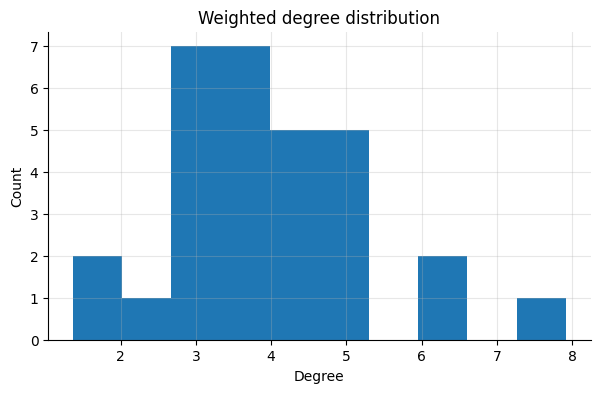

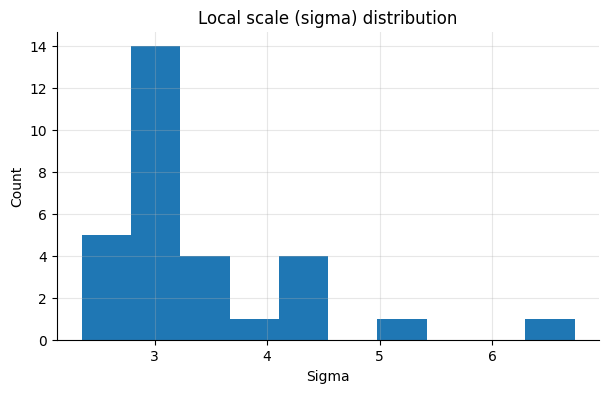

In [60]:
# =========================
# Build similarity graph W
# =========================

from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt


def build_self_tuning_knn_affinity(
    X_scaled: np.ndarray,
    symbols: list[str],
    k_neighbors: int = 7,
) -> tuple[np.ndarray, pd.DataFrame, dict]:
    """
    Xây affinity matrix W bằng self-tuning Gaussian trên kNN graph.

    Ý tưởng:
    - tìm k nearest neighbors cho mỗi stock
    - sigma_i = khoảng cách tới neighbor thứ k của điểm i
    - affinity(i,j) = exp( - d(i,j)^2 / (sigma_i * sigma_j) )
    - chỉ giữ cạnh nếu i nằm trong kNN của j hoặc j nằm trong kNN của i
    - sau đó đối xứng hóa W

    Parameters
    ----------
    X_scaled : np.ndarray
        Ma trận feature đã scale, shape (n_stocks, n_features)
    symbols : list[str]
        Danh sách mã cổ phiếu theo đúng thứ tự dòng của X_scaled
    k_neighbors : int
        Số láng giềng gần nhất

    Returns
    -------
    W : np.ndarray
        Affinity matrix đối xứng, shape (n, n)
    W_df : pd.DataFrame
        Bản DataFrame của W
    graph_info : dict
        Thông tin phụ về graph
    """
    n = X_scaled.shape[0]
    if n < 3:
        raise ValueError("Cần ít nhất 3 mã cổ phiếu để xây graph.")

    # đảm bảo k hợp lệ
    k = min(k_neighbors, n - 1)
    if k < 2:
        k = min(2, n - 1)

    # tìm k+1 neighbors vì neighbor đầu tiên là chính nó
    nbrs = NearestNeighbors(n_neighbors=k + 1, metric="euclidean")
    nbrs.fit(X_scaled)

    distances, indices = nbrs.kneighbors(X_scaled)

    # bỏ self-neighbor ở cột đầu
    knn_dist = distances[:, 1:]   # shape (n, k)
    knn_idx = indices[:, 1:]      # shape (n, k)

    # sigma_i = khoảng cách tới neighbor xa nhất trong kNN của i
    sigma = knn_dist[:, -1].copy()

    # chống chia cho 0
    eps = 1e-12
    sigma = np.where(sigma <= eps, eps, sigma)

    # xây W
    W = np.zeros((n, n), dtype=float)

    for i in range(n):
        for neighbor_pos in range(k):
            j = knn_idx[i, neighbor_pos]
            d_ij = knn_dist[i, neighbor_pos]

            denom = sigma[i] * sigma[j]
            denom = max(denom, eps)

            w_ij = np.exp(-(d_ij ** 2) / denom)
            W[i, j] = max(W[i, j], w_ij)

    # union kNN graph + đối xứng hóa bằng max
    W = np.maximum(W, W.T)

    # đặt diagonal = 0 để graph không tự nối vào chính nó
    np.fill_diagonal(W, 0.0)

    W_df = pd.DataFrame(W, index=symbols, columns=symbols)

    # graph stats
    nonzero_mask = W > 0
    edge_count_undirected = int(np.sum(np.triu(nonzero_mask, k=1)))
    density = edge_count_undirected / (n * (n - 1) / 2)

    degree = W.sum(axis=1)
    nnz_per_row = (W > 0).sum(axis=1)

    graph_info = {
        "n_nodes": n,
        "k_neighbors_used": k,
        "edge_count_undirected": edge_count_undirected,
        "graph_density": density,
        "degree_min": degree.min(),
        "degree_mean": degree.mean(),
        "degree_max": degree.max(),
        "nnz_row_min": nnz_per_row.min(),
        "nnz_row_mean": nnz_per_row.mean(),
        "nnz_row_max": nnz_per_row.max(),
        "sigma_min": sigma.min(),
        "sigma_mean": sigma.mean(),
        "sigma_max": sigma.max(),
        "sigma": sigma,
        "degree_vector": degree,
        "nnz_per_row": nnz_per_row,
        "knn_indices": knn_idx,
        "knn_distances": knn_dist,
    }

    return W, W_df, graph_info


def graph_diagnostics_table(graph_info: dict) -> pd.DataFrame:
    """
    Bảng tóm tắt graph để kiểm tra nhanh.
    """
    return pd.DataFrame({
        "metric": [
            "n_nodes",
            "k_neighbors_used",
            "edge_count_undirected",
            "graph_density",
            "degree_min",
            "degree_mean",
            "degree_max",
            "nnz_row_min",
            "nnz_row_mean",
            "nnz_row_max",
            "sigma_min",
            "sigma_mean",
            "sigma_max",
        ],
        "value": [
            graph_info["n_nodes"],
            graph_info["k_neighbors_used"],
            graph_info["edge_count_undirected"],
            graph_info["graph_density"],
            graph_info["degree_min"],
            graph_info["degree_mean"],
            graph_info["degree_max"],
            graph_info["nnz_row_min"],
            graph_info["nnz_row_mean"],
            graph_info["nnz_row_max"],
            graph_info["sigma_min"],
            graph_info["sigma_mean"],
            graph_info["sigma_max"],
        ]
    })


def plot_graph_diagnostics(graph_info: dict):
    """
    Hai biểu đồ nhỏ để xem graph có ổn không:
    - histogram degree
    - histogram sigma local scale
    """
    degree = graph_info["degree_vector"]
    sigma = graph_info["sigma"]

    plt.figure(figsize=(7, 4))
    plt.hist(degree, bins=10)
    plt.title("Weighted degree distribution")
    plt.xlabel("Degree")
    plt.ylabel("Count")
    plt.show()

    plt.figure(figsize=(7, 4))
    plt.hist(sigma, bins=10)
    plt.title("Local scale (sigma) distribution")
    plt.xlabel("Sigma")
    plt.ylabel("Count")
    plt.show()



symbols_for_graph = prep_artifacts["symbols"]

W, W_df, graph_info = build_self_tuning_knn_affinity(
    X_scaled=X_scaled,
    symbols=symbols_for_graph,
    k_neighbors=7,
)

graph_report = graph_diagnostics_table(graph_info)

print("W shape:", W.shape)
print("\nGraph report:")
display(graph_report.round(4))

print("\nSample of W:")
display(W_df.iloc[:8, :8].round(4))

plot_graph_diagnostics(graph_info)


## Spectral Decomposition and Eigengap Diagnostics

From `W`, the notebook derives normalized Laplacian-related eigenvectors/eigenvalues,
then inspects eigengap to guide cluster-count selection.

This section produces the spectral basis used by graph clustering.


L_sym shape: (30, 30)
Eigenvectors shape: (30, 30)

Spectral report:


,metric,value
0,n_nodes,30.000000
1,n_connected_components,1.000000
2,degree_min,1.364264
3,degree_mean,3.974989
4,degree_max,7.918523
5,smallest_eigenvalue,0.000000
6,second_smallest_eigenvalue,0.171487
7,third_smallest_eigenvalue,0.316740



Eigengap table:


,k_index,lambda_k,lambda_kplus1,eigengap
0,1,0.000000,0.171487,0.171487
1,2,0.171487,0.316740,0.145253
2,3,0.316740,0.606992,0.290252
3,4,0.606992,0.685111,0.078119
4,5,0.685111,0.739887,0.054776
5,6,0.739887,0.824507,0.084620
6,7,0.824507,0.857430,0.032923
7,8,0.857430,0.970172,0.112741


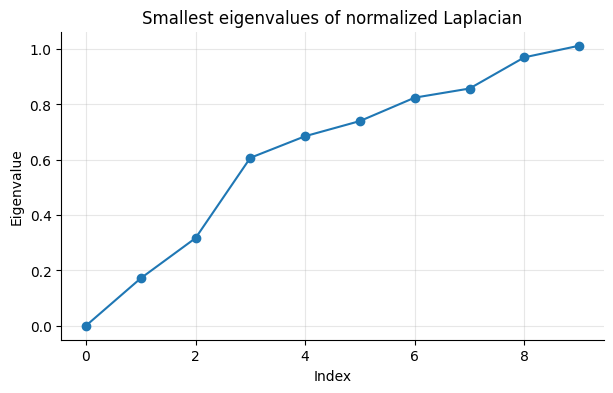

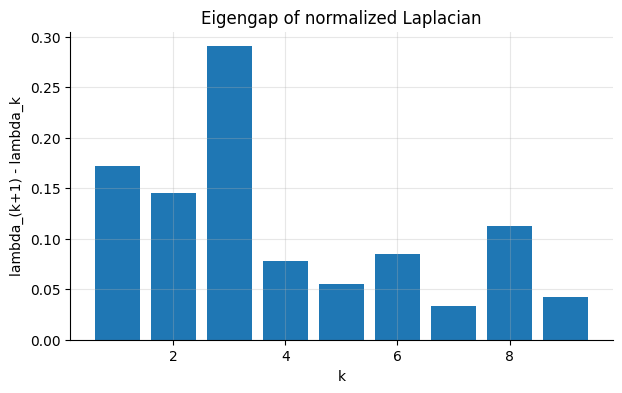


Demo spectral embedding for K=4:


,u1,u2,u3,u4
BID,-0.2198,0.7902,-0.2070,0.5333
BVH,-0.4468,0.5786,-0.6095,-0.3068
CTG,-0.4006,-0.0283,-0.8100,0.4272
FPT,0.9832,0.0117,0.1823,-0.0028
GAS,0.9345,0.0664,-0.3497,-0.0064
HDB,-0.7569,-0.5892,0.0148,0.2823
HPG,-0.3202,-0.5142,0.7945,0.0425
KDH,0.9125,-0.3198,-0.2489,-0.0555
MBB,-0.3741,-0.5056,0.7774,-0.0111
MSN,0.8955,-0.2132,-0.0089,-0.3905


In [61]:
# =========================
# Spectral embedding from affinity matrix W
# =========================

from scipy.linalg import eigh
from scipy.sparse.csgraph import connected_components
import matplotlib.pyplot as plt


def build_normalized_laplacian(W: np.ndarray, eps: float = 1e-12) -> tuple[np.ndarray, np.ndarray]:
    """
    Xây normalized Laplacian:
        L_sym = I - D^{-1/2} W D^{-1/2}

    Returns
    -------
    L_sym : np.ndarray
        Symmetric normalized Laplacian
    degree : np.ndarray
        Weighted degree vector
    """
    W = np.asarray(W, dtype=float)

    if W.shape[0] != W.shape[1]:
        raise ValueError("W phải là ma trận vuông.")

    # degree
    degree = W.sum(axis=1)

    if np.any(degree <= eps):
        raise ValueError(
            "Graph có node bậc bằng 0. Hãy tăng k_neighbors hoặc kiểm tra lại feature/graph."
        )

    D_inv_sqrt = np.diag(1.0 / np.sqrt(np.maximum(degree, eps)))
    I = np.eye(W.shape[0])

    L_sym = I - D_inv_sqrt @ W @ D_inv_sqrt

    # đối xứng hóa nhẹ để chống sai số số học
    L_sym = 0.5 * (L_sym + L_sym.T)

    return L_sym, degree


def compute_spectral_decomposition(
    W: np.ndarray,
    n_components: int | None = None,
) -> dict:
    """
    Tính eigen decomposition của normalized Laplacian.

    Returns
    -------
    result : dict
        Chứa L_sym, degree, eigenvalues, eigenvectors, connected components info
    """
    n = W.shape[0]
    if n_components is None:
        n_components = min(10, n)

    L_sym, degree = build_normalized_laplacian(W)

    # toàn bộ eigenpairs cho dễ phân tích eigengap
    eigenvalues, eigenvectors = eigh(L_sym)

    # sort tăng dần cho chắc
    order = np.argsort(eigenvalues)
    eigenvalues = eigenvalues[order]
    eigenvectors = eigenvectors[:, order]

    # kiểm tra connected components trên graph nhị phân
    adjacency_binary = (W > 0).astype(int)
    n_cc, labels_cc = connected_components(adjacency_binary, directed=False)

    result = {
        "L_sym": L_sym,
        "degree": degree,
        "eigenvalues": eigenvalues,
        "eigenvectors": eigenvectors,
        "n_components_requested": n_components,
        "n_connected_components": n_cc,
        "connected_component_labels": labels_cc,
    }
    return result


def build_spectral_embedding(
    eigenvectors: np.ndarray,
    n_clusters: int,
    drop_first: bool = True,
    row_normalize: bool = True,
    eps: float = 1e-12,
) -> np.ndarray:
    """
    Tạo spectral embedding để đem đi KMeans.

    Thông dụng:
    - bỏ eigenvector đầu tiên nếu graph connected
    - lấy tiếp theo n_clusters eigenvectors
    - row-normalize

    Parameters
    ----------
    eigenvectors : np.ndarray
        Eigenvectors của normalized Laplacian, cột đã sắp theo eigenvalue tăng dần
    n_clusters : int
        Số cụm dự kiến
    drop_first : bool
        Có bỏ eigenvector đầu tiên hay không
    row_normalize : bool
        Có chuẩn hóa từng dòng hay không

    Returns
    -------
    U : np.ndarray
        Spectral embedding shape (n_samples, n_clusters)
    """
    if drop_first:
        U = eigenvectors[:, 1:n_clusters + 1].copy()
    else:
        U = eigenvectors[:, :n_clusters].copy()

    if row_normalize:
        row_norms = np.linalg.norm(U, axis=1, keepdims=True)
        row_norms = np.maximum(row_norms, eps)
        U = U / row_norms

    return U


def compute_eigengap_table(eigenvalues: np.ndarray, max_k: int = 8) -> pd.DataFrame:
    """
    Tạo bảng eigengap để hỗ trợ chọn K.
    Nếu dùng normalized Laplacian:
    - thường nhìn gap giữa lambda_k và lambda_{k+1}
    - K ứng viên là vị trí có gap lớn

    Ở đây, nếu bỏ eigenvector đầu tiên khi clustering,
    ta vẫn thường xét gap trên dãy eigenvalues từ đầu.
    """
    max_k = min(max_k, len(eigenvalues) - 1)

    rows = []
    for k in range(1, max_k + 1):
        gap = eigenvalues[k] - eigenvalues[k - 1]
        rows.append({
            "k_index": k,
            "lambda_k": eigenvalues[k - 1],
            "lambda_kplus1": eigenvalues[k],
            "eigengap": gap,
        })

    return pd.DataFrame(rows)


def plot_eigenvalues_and_gaps(eigenvalues: np.ndarray, max_points: int = 10):
    """
    Vẽ:
    - eigenvalues đầu tiên
    - eigengap giữa các eigenvalues liên tiếp
    """
    m = min(max_points, len(eigenvalues))
    vals = eigenvalues[:m]

    plt.figure(figsize=(7, 4))
    plt.plot(range(m), vals, marker="o")
    plt.title("Smallest eigenvalues of normalized Laplacian")
    plt.xlabel("Index")
    plt.ylabel("Eigenvalue")
    plt.grid(True, alpha=0.3)
    plt.show()

    if m >= 2:
        gaps = np.diff(vals)
        plt.figure(figsize=(7, 4))
        plt.bar(range(1, len(gaps) + 1), gaps)
        plt.title("Eigengap of normalized Laplacian")
        plt.xlabel("k")
        plt.ylabel("lambda_(k+1) - lambda_k")
        plt.grid(True, axis="y", alpha=0.3)
        plt.show()


def spectral_summary_table(spec_result: dict) -> pd.DataFrame:
    eigenvalues = spec_result["eigenvalues"]
    degree = spec_result["degree"]

    return pd.DataFrame({
        "metric": [
            "n_nodes",
            "n_connected_components",
            "degree_min",
            "degree_mean",
            "degree_max",
            "smallest_eigenvalue",
            "second_smallest_eigenvalue",
            "third_smallest_eigenvalue",
        ],
        "value": [
            len(degree),
            spec_result["n_connected_components"],
            degree.min(),
            degree.mean(),
            degree.max(),
            eigenvalues[0] if len(eigenvalues) > 0 else np.nan,
            eigenvalues[1] if len(eigenvalues) > 1 else np.nan,
            eigenvalues[2] if len(eigenvalues) > 2 else np.nan,
        ]
    })



spec_result = compute_spectral_decomposition(W)

L_sym = spec_result["L_sym"]
degree_vec = spec_result["degree"]
eigenvalues = spec_result["eigenvalues"]
eigenvectors = spec_result["eigenvectors"]

spec_report = spectral_summary_table(spec_result)
eigengap_table = compute_eigengap_table(eigenvalues, max_k=8)

print("L_sym shape:", L_sym.shape)
print("Eigenvectors shape:", eigenvectors.shape)

print("\nSpectral report:")
display(spec_report.round(6))

print("\nEigengap table:")
display(eigengap_table.round(6))

plot_eigenvalues_and_gaps(eigenvalues, max_points=10)

# embedding demo để xem trước, ví dụ K=4
U_demo = build_spectral_embedding(
    eigenvectors=eigenvectors,
    n_clusters=4,
    drop_first=True,
    row_normalize=True,
)

U_demo_df = pd.DataFrame(
    U_demo,
    index=prep_artifacts["symbols"],
    columns=[f"u{i}" for i in range(1, U_demo.shape[1] + 1)]
)

print("\nDemo spectral embedding for K=4:")
display(U_demo_df.round(4).head(10))


## Hyperparameter Tuning and 3-Method Benchmark

This section follows one main pipeline:

`Raw price -> Feature Engineering -> kNN Graph -> Gaussian Kernel -> Markov Matrix -> Diffusion Maps -> Graph Laplacian -> Spectral Clustering`

Only three methods are benchmarked:
- `spectral_diffusion` (main method above)
- `kmeans_features` (baseline on `X_scaled`)
- `dbscan_features` (density baseline on `X_scaled`)

Cluster count selection for spectral route combines eigengap, silhouette, and cluster-size balance.


In [62]:
# =========================
# Tune spectral diffusion + method benchmark
# =========================

from sklearn.cluster import DBSCAN, KMeans
from sklearn.metrics import (
    calinski_harabasz_score,
    davies_bouldin_score,
    silhouette_samples,
    silhouette_score,
)
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import MinMaxScaler

RANDOM_STATE = 42
PALETTE = plt.cm.tab10.colors
METHOD_NAME_MAP = {
    "kmeans_features": "KMeans labels (fit on X)",
    "kmeans_diffusion": "KMeans labels (fit on diffusion)",
    "dbscan_features": "DBSCAN labels (fit on X)",
    "spectral_base": "Spectral labels (original graph)",
    "spectral_reaffinity": "Spectral labels (diffusion re-affinity)",
}


def _normalize_01(values: np.ndarray) -> np.ndarray:
    values = np.asarray(values, dtype=float)
    if values.size == 0:
        return values

    finite_mask = np.isfinite(values)
    if not finite_mask.any():
        return np.zeros_like(values, dtype=float)

    clean = values.copy()
    clean[~finite_mask] = np.nanmin(clean[finite_mask])
    vmin, vmax = float(np.min(clean)), float(np.max(clean))
    if np.isclose(vmax, vmin):
        return np.zeros_like(clean, dtype=float)
    return (clean - vmin) / (vmax - vmin)


def safe_metric(metric_fn, X: np.ndarray, labels: np.ndarray) -> float:
    labels = np.asarray(labels)
    if labels.size == 0:
        return float("nan")

    if np.all(labels == -1):
        return float("nan")

    if np.any(labels == -1):
        keep = labels != -1
        X_eval = X[keep]
        y_eval = labels[keep]
    else:
        X_eval = X
        y_eval = labels

    if len(np.unique(y_eval)) < 2:
        return float("nan")

    try:
        return float(metric_fn(X_eval, y_eval))
    except Exception:
        return float("nan")


def evaluate_clustering(X_eval: np.ndarray, labels: np.ndarray) -> dict:
    labels = np.asarray(labels)
    non_noise = labels[labels != -1]
    n_clusters = len(np.unique(non_noise)) if non_noise.size else 0

    return {
        "n_clusters": int(n_clusters),
        "silhouette": safe_metric(silhouette_score, X_eval, labels),
        "davies_bouldin": safe_metric(davies_bouldin_score, X_eval, labels),
        "calinski_harabasz": safe_metric(calinski_harabasz_score, X_eval, labels),
        "has_noise": bool(np.any(labels == -1)),
    }


def build_markov_matrix(W: np.ndarray, eps: float = 1e-12) -> tuple[np.ndarray, np.ndarray]:
    d = np.asarray(W.sum(axis=1), dtype=float)
    d = np.where(d <= eps, eps, d)
    P = W / d[:, None]
    return P, d


def alpha_normalize_affinity(
    W: np.ndarray,
    alpha: float = 1.0,
    eps: float = 1e-12,
) -> tuple[np.ndarray, np.ndarray]:
    W = np.asarray(W, dtype=float)
    q = np.asarray(W.sum(axis=1), dtype=float)
    q = np.where(q <= eps, eps, q)

    if np.isclose(alpha, 0.0):
        W_alpha = W.copy()
    else:
        scale = np.power(q, alpha)
        W_alpha = W / np.maximum(np.outer(scale, scale), eps)

    W_alpha = 0.5 * (W_alpha + W_alpha.T)
    np.fill_diagonal(W_alpha, 0.0)
    return W_alpha, q


def diffusion_map_embedding(
    W: np.ndarray,
    n_components: int = 3,
    t: int = 2,
    alpha: float = 1.0,
    eps: float = 1e-12,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, dict]:
    W_alpha, q = alpha_normalize_affinity(W=W, alpha=alpha, eps=eps)
    P, degree = build_markov_matrix(W=W_alpha, eps=eps)

    D_inv_sqrt = np.diag(1.0 / np.sqrt(np.maximum(degree, eps)))
    S = D_inv_sqrt @ W_alpha @ D_inv_sqrt
    S = 0.5 * (S + S.T)

    eigvals, eigvecs = np.linalg.eigh(S)
    order = np.argsort(eigvals)[::-1]
    eigvals = eigvals[order]
    eigvecs = eigvecs[:, order]

    positive_nontrivial = [idx for idx in range(1, len(eigvals)) if eigvals[idx] > eps]
    selected_idx = positive_nontrivial[:n_components]
    if len(selected_idx) < n_components:
        fallback = [idx for idx in range(1, len(eigvals)) if idx not in selected_idx]
        selected_idx = (selected_idx + fallback)[:n_components]

    vals = np.clip(eigvals[selected_idx], a_min=0.0, a_max=None)
    vecs_s = eigvecs[:, selected_idx]
    vecs_p = D_inv_sqrt @ vecs_s
    emb = vecs_p * np.power(vals, t)

    info = {
        "W_alpha": W_alpha,
        "q_density_proxy": q,
        "degree_alpha": degree,
        "selected_indices": selected_idx,
        "alpha": float(alpha),
        "t": int(t),
    }
    return emb, eigvals, P, info


def select_k_by_eigengap_and_silhouette(
    eigenvalues: np.ndarray,
    eigenvectors: np.ndarray,
    diffusion_embedding: np.ndarray,
    k_min: int = 2,
    k_max: int = 8,
    candidate_k_values: tuple[int, ...] | list[int] | None = None,
) -> tuple[int, pd.DataFrame]:
    n = eigenvectors.shape[0]

    if candidate_k_values is None:
        k_candidates = list(range(max(2, k_min), min(k_max, n - 1) + 1))
    else:
        k_candidates = sorted({int(k) for k in candidate_k_values if 2 <= int(k) <= n - 1})

    if not k_candidates:
        raise ValueError("No valid cluster_k candidates for spectral selection.")

    rows = []
    for k in k_candidates:
        U = build_spectral_embedding(
            eigenvectors=eigenvectors,
            n_clusters=k,
            drop_first=True,
            row_normalize=True,
        )
        labels = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=100).fit_predict(U)

        counts = np.bincount(labels)
        min_cluster_size = int(counts.min())
        balance_ratio = float(min_cluster_size / len(labels))

        sil = safe_metric(silhouette_score, diffusion_embedding, labels)
        eigengap = float(eigenvalues[k] - eigenvalues[k - 1])

        rows.append(
            {
                "k": int(k),
                "eigengap": eigengap,
                "silhouette_diffusion": sil,
                "min_cluster_size": min_cluster_size,
                "balance_ratio": balance_ratio,
            }
        )

    table = pd.DataFrame(rows)
    table["eigengap_norm"] = _normalize_01(table["eigengap"].to_numpy())
    table["silhouette_norm"] = _normalize_01(table["silhouette_diffusion"].to_numpy())
    table["balance_norm"] = _normalize_01(table["balance_ratio"].to_numpy())
    table["score"] = (
        0.60 * table["silhouette_norm"]
        + 0.30 * table["eigengap_norm"]
        + 0.10 * table["balance_norm"]
    )

    best_row = table.sort_values(
        ["score", "silhouette_diffusion", "eigengap"],
        ascending=[False, False, False],
    ).iloc[0]
    return int(best_row["k"]), table


def _fit_spectral_variant(
    W_variant: np.ndarray,
    X_scaled: np.ndarray,
    diffusion_embedding: np.ndarray,
    variant_name: str,
    candidate_k_values: tuple[int, ...],
) -> dict:
    spec_variant = compute_spectral_decomposition(W_variant)

    best_k_variant, k_table_variant = select_k_by_eigengap_and_silhouette(
        eigenvalues=spec_variant["eigenvalues"],
        eigenvectors=spec_variant["eigenvectors"],
        diffusion_embedding=diffusion_embedding,
        candidate_k_values=candidate_k_values,
    )

    U_variant = build_spectral_embedding(
        eigenvectors=spec_variant["eigenvectors"],
        n_clusters=best_k_variant,
        drop_first=True,
        row_normalize=True,
    )
    labels_variant = KMeans(
        n_clusters=best_k_variant,
        random_state=RANDOM_STATE,
        n_init=100,
    ).fit_predict(U_variant)

    metrics_x = evaluate_clustering(X_scaled, labels_variant)
    metrics_phi = evaluate_clustering(diffusion_embedding, labels_variant)

    return {
        "variant": variant_name,
        "W": W_variant,
        "spec_result": spec_variant,
        "best_k": int(best_k_variant),
        "k_search_table": k_table_variant,
        "U_norm": U_variant,
        "labels": labels_variant,
        "metrics_X": metrics_x,
        "metrics_diffusion": metrics_phi,
        "silhouette_X": metrics_x["silhouette"],
        "davies_bouldin_X": metrics_x["davies_bouldin"],
        "calinski_harabasz_X": metrics_x["calinski_harabasz"],
        "silhouette_diffusion": metrics_phi["silhouette"],
        "davies_bouldin_diffusion": metrics_phi["davies_bouldin"],
        "calinski_harabasz_diffusion": metrics_phi["calinski_harabasz"],
    }


def run_spectral_once(
    X_scaled: np.ndarray,
    symbols: list[str],
    k_neighbors: int,
    diffusion_t: int,
    diffusion_alpha: float = 1.0,
    cluster_k_grid: tuple[int, ...] = (2, 3, 4, 5, 6),
    use_reaffinity: bool = True,
) -> dict:
    candidate_k_values = tuple(
        sorted({int(k) for k in cluster_k_grid if 2 <= int(k) <= len(symbols) - 1})
    )
    if not candidate_k_values:
        candidate_k_values = tuple(range(2, min(6, len(symbols) - 1) + 1))

    W_cfg, _, graph_info_cfg = build_self_tuning_knn_affinity(
        X_scaled=X_scaled,
        symbols=symbols,
        k_neighbors=k_neighbors,
    )

    diff_emb_cfg, diff_eigs_cfg, P_cfg, diff_info_cfg = diffusion_map_embedding(
        W=W_cfg,
        n_components=3,
        t=diffusion_t,
        alpha=diffusion_alpha,
    )

    base_variant = _fit_spectral_variant(
        W_variant=W_cfg,
        X_scaled=X_scaled,
        diffusion_embedding=diff_emb_cfg,
        variant_name="base",
        candidate_k_values=candidate_k_values,
    )

    variant_runs = {"base": base_variant}
    reaffinity_graph_info = None

    if use_reaffinity and diff_emb_cfg.shape[0] >= 3:
        W_re, _, reaffinity_graph_info = build_self_tuning_knn_affinity(
            X_scaled=diff_emb_cfg,
            symbols=symbols,
            k_neighbors=min(k_neighbors, max(2, len(symbols) - 1)),
        )
        variant_runs["reaffinity"] = _fit_spectral_variant(
            W_variant=W_re,
            X_scaled=X_scaled,
            diffusion_embedding=diff_emb_cfg,
            variant_name="reaffinity",
            candidate_k_values=candidate_k_values,
        )

    selected_variant = max(
        variant_runs.values(),
        key=lambda item: (
            -np.inf if np.isnan(item["silhouette_diffusion"]) else item["silhouette_diffusion"],
            np.inf if np.isnan(item["davies_bouldin_diffusion"]) else -item["davies_bouldin_diffusion"],
            -np.inf if np.isnan(item["silhouette_X"]) else item["silhouette_X"],
            item["best_k"],
        ),
    )

    return {
        "W_initial": W_cfg,
        "W": selected_variant["W"],
        "P": P_cfg,
        "graph_info": graph_info_cfg,
        "reaffinity_graph_info": reaffinity_graph_info,
        "diffusion_info": diff_info_cfg,
        "diffusion_embedding": diff_emb_cfg,
        "diffusion_eigenvalues": diff_eigs_cfg,
        "variant_runs": variant_runs,
        "selected_variant": selected_variant["variant"],
        "spec_result": selected_variant["spec_result"],
        "best_k": selected_variant["best_k"],
        "k_search_table": selected_variant["k_search_table"],
        "U_norm": selected_variant["U_norm"],
        "labels": selected_variant["labels"],
        "final_silhouette_X": selected_variant["silhouette_X"],
        "final_davies_bouldin_X": selected_variant["davies_bouldin_X"],
        "final_calinski_harabasz_X": selected_variant["calinski_harabasz_X"],
        "final_silhouette_diffusion": selected_variant["silhouette_diffusion"],
        "final_davies_bouldin_diffusion": selected_variant["davies_bouldin_diffusion"],
        "final_calinski_harabasz_diffusion": selected_variant["calinski_harabasz_diffusion"],
        "k_neighbors": int(k_neighbors),
        "diffusion_t": int(diffusion_t),
        "diffusion_alpha": float(diffusion_alpha),
        "candidate_k_values": candidate_k_values,
    }


def tune_spectral_hyperparams(
    X_scaled: np.ndarray,
    symbols: list[str],
    k_neighbor_grid: tuple[int, ...] = (5, 7, 9),
    diffusion_t_grid: tuple[int, ...] = (1, 2, 3, 4, 5, 6, 7, 8),
    diffusion_alpha_grid: tuple[float, ...] = (0.0, 0.5, 1.0),
    cluster_k_grid: tuple[int, ...] = (2, 3, 4, 5, 6),
    local_t_radius: int = 0,
    use_reaffinity: bool = True,
) -> tuple[dict, pd.DataFrame]:
    n = len(symbols)
    valid_neighbors = sorted({min(max(2, int(k)), n - 1) for k in k_neighbor_grid if n > 2})
    valid_alphas = sorted({float(alpha) for alpha in diffusion_alpha_grid})
    valid_t = sorted({max(1, int(t)) for t in diffusion_t_grid})

    if not valid_neighbors or not valid_t:
        raise ValueError("Invalid hyperparameter grid for spectral diffusion tuning.")

    def build_row(phase: str, result: dict) -> dict:
        top_table = result["k_search_table"].sort_values("score", ascending=False)
        top_score = float(top_table.iloc[0]["score"]) if not top_table.empty else float("nan")
        return {
            "phase": phase,
            "k_neighbors": result["k_neighbors"],
            "diffusion_alpha": result["diffusion_alpha"],
            "diffusion_t": result["diffusion_t"],
            "best_k": result["best_k"],
            "selected_variant": result["selected_variant"],
            "spectral_score": top_score,
            "silhouette_X": result["final_silhouette_X"],
            "davies_bouldin_X": result["final_davies_bouldin_X"],
            "calinski_harabasz_X": result["final_calinski_harabasz_X"],
            "silhouette_diffusion": result["final_silhouette_diffusion"],
            "davies_bouldin_diffusion": result["final_davies_bouldin_diffusion"],
            "calinski_harabasz_diffusion": result["final_calinski_harabasz_diffusion"],
        }

    def candidate_rank(result: dict) -> tuple[float, float, float, int]:
        top_table = result["k_search_table"].sort_values("score", ascending=False)
        spectral_score = float(top_table.iloc[0]["score"]) if not top_table.empty else float("nan")
        sil = result["final_silhouette_diffusion"]
        db = result["final_davies_bouldin_diffusion"]
        return (
            -np.inf if pd.isna(sil) else float(sil),
            np.inf if pd.isna(db) else -float(db),
            -np.inf if pd.isna(spectral_score) else float(spectral_score),
            int(result["best_k"]),
        )

    rows = []
    best_run = None
    best_rank = None

    for k_neighbors in valid_neighbors:
        for diffusion_alpha in valid_alphas:
            for diffusion_t in valid_t:
                result = run_spectral_once(
                    X_scaled=X_scaled,
                    symbols=symbols,
                    k_neighbors=k_neighbors,
                    diffusion_t=diffusion_t,
                    diffusion_alpha=diffusion_alpha,
                    cluster_k_grid=cluster_k_grid,
                    use_reaffinity=use_reaffinity,
                )
                rank = candidate_rank(result)
                rows.append(build_row("coarse", result))

                if best_rank is None or rank > best_rank:
                    best_run = result
                    best_rank = rank

    if best_run is None:
        raise RuntimeError("Hyperparameter tuning did not produce any valid spectral run.")

    best_t = int(best_run["diffusion_t"])
    refined_t_values = sorted(
        {
            t
            for t in range(max(1, best_t - int(local_t_radius)), best_t + int(local_t_radius) + 1)
            if t not in valid_t
        }
    )

    for diffusion_t in refined_t_values:
        result = run_spectral_once(
            X_scaled=X_scaled,
            symbols=symbols,
            k_neighbors=best_run["k_neighbors"],
            diffusion_t=diffusion_t,
            diffusion_alpha=best_run["diffusion_alpha"],
            cluster_k_grid=cluster_k_grid,
            use_reaffinity=use_reaffinity,
        )
        rank = candidate_rank(result)
        rows.append(build_row("local_refine", result))

        if best_rank is None or rank > best_rank:
            best_run = result
            best_rank = rank

    tuning_df = pd.DataFrame(rows).sort_values(
        ["silhouette_diffusion", "davies_bouldin_diffusion", "spectral_score"],
        ascending=[False, True, False],
    ).reset_index(drop=True)
    return best_run, tuning_df


def _fit_dbscan_auto_eps(
    X: np.ndarray,
    min_samples: int = 3,
    quantiles: tuple[float, ...] = (0.20, 0.30, 0.40, 0.50, 0.60),
) -> tuple[np.ndarray, float]:
    if X.shape[0] <= min_samples:
        return np.full(X.shape[0], -1, dtype=int), float("nan")

    nn = NearestNeighbors(n_neighbors=min_samples, metric="euclidean")
    nn.fit(X)
    dists, _ = nn.kneighbors(X)
    kth_dist = np.sort(dists[:, -1])
    eps_grid = sorted({float(np.quantile(kth_dist, q)) for q in quantiles})

    best_labels = None
    best_eps = float("nan")
    best_score = -np.inf
    best_n_clusters = -1

    for eps in eps_grid:
        labels = DBSCAN(eps=eps, min_samples=min_samples).fit_predict(X)
        score = safe_metric(silhouette_score, X, labels)
        score = -np.inf if np.isnan(score) else score
        uniq = labels[labels != -1]
        n_clusters = len(np.unique(uniq)) if uniq.size else 0
        if n_clusters < 2:
            continue

        if best_labels is None or score > best_score or (
            np.isclose(score, best_score) and n_clusters > best_n_clusters
        ):
            best_labels = labels
            best_eps = float(eps)
            best_score = score
            best_n_clusters = n_clusters

    if best_labels is None:
        fallback_eps = float(np.median(kth_dist))
        best_labels = DBSCAN(eps=fallback_eps, min_samples=min_samples).fit_predict(X)
        best_eps = fallback_eps

    return best_labels, best_eps


def compare_clustering_methods(
    X_scaled: np.ndarray,
    diffusion_embedding: np.ndarray,
    best_k: int,
    spectral_base_labels: np.ndarray | None = None,
    spectral_reaffinity_labels: np.ndarray | None = None,
) -> tuple[pd.DataFrame, dict, dict]:
    labels_by_method: dict[str, np.ndarray] = {}

    labels_by_method["kmeans_features"] = KMeans(
        n_clusters=best_k,
        random_state=RANDOM_STATE,
        n_init=100,
    ).fit_predict(X_scaled)
    labels_by_method["kmeans_diffusion"] = KMeans(
        n_clusters=best_k,
        random_state=RANDOM_STATE,
        n_init=100,
    ).fit_predict(diffusion_embedding)

    dbscan_labels, dbscan_eps = _fit_dbscan_auto_eps(X_scaled, min_samples=3)
    labels_by_method["dbscan_features"] = dbscan_labels

    if spectral_base_labels is not None:
        labels_by_method["spectral_base"] = np.asarray(spectral_base_labels)
    if spectral_reaffinity_labels is not None:
        labels_by_method["spectral_reaffinity"] = np.asarray(spectral_reaffinity_labels)

    rows = []
    for method_name, labels in labels_by_method.items():
        metrics_x = evaluate_clustering(X_scaled, labels)
        metrics_phi = evaluate_clustering(diffusion_embedding, labels)
        rows.append(
            {
                "method": method_name,
                "method_pretty": METHOD_NAME_MAP.get(method_name, method_name),
                "n_clusters_found": metrics_x["n_clusters"],
                "has_noise": metrics_x["has_noise"],
                "silhouette_X": metrics_x["silhouette"],
                "davies_bouldin_X": metrics_x["davies_bouldin"],
                "calinski_harabasz_X": metrics_x["calinski_harabasz"],
                "silhouette_diffusion": metrics_phi["silhouette"],
                "davies_bouldin_diffusion": metrics_phi["davies_bouldin"],
                "calinski_harabasz_diffusion": metrics_phi["calinski_harabasz"],
            }
        )

    metrics_df = pd.DataFrame(rows)
    order_map = {
        "spectral_reaffinity": 0,
        "spectral_base": 1,
        "kmeans_diffusion": 2,
        "kmeans_features": 3,
        "dbscan_features": 4,
    }
    metrics_df["sort_key"] = metrics_df["method"].map(order_map).fillna(99)
    metrics_df = metrics_df.sort_values(
        ["sort_key", "silhouette_diffusion", "silhouette_X"],
        ascending=[True, False, False],
    ).drop(columns="sort_key").reset_index(drop=True)

    meta = {
        "dbscan_eps": float(dbscan_eps),
        "dbscan_min_samples": 3,
        "methods_evaluated": metrics_df["method"].tolist(),
    }
    return metrics_df, labels_by_method, meta


def summarize_proposed_method_advantage(
    metrics_df: pd.DataFrame,
    proposed_method: str = "spectral_reaffinity",
) -> pd.DataFrame:
    if proposed_method not in set(metrics_df["method"]):
        return pd.DataFrame()

    metric_specs = [
        ("silhouette_X", "Silhouette (X)", "higher"),
        ("davies_bouldin_X", "Davies-Bouldin (X)", "lower"),
        ("calinski_harabasz_X", "Calinski-Harabasz (X)", "higher"),
        ("silhouette_diffusion", "Silhouette (diffusion)", "higher"),
        ("davies_bouldin_diffusion", "Davies-Bouldin (diffusion)", "lower"),
        ("calinski_harabasz_diffusion", "Calinski-Harabasz (diffusion)", "higher"),
    ]

    proposed_row = metrics_df.loc[metrics_df["method"] == proposed_method].iloc[0]
    baseline_df = metrics_df.loc[metrics_df["method"] != proposed_method].copy()

    rows = []
    for metric_col, metric_name, direction in metric_specs:
        if pd.isna(proposed_row.get(metric_col, np.nan)):
            continue

        valid = baseline_df[["method", "method_pretty", metric_col]].dropna()
        if valid.empty:
            continue

        if direction == "higher":
            best_idx = valid[metric_col].idxmax()
            rank = int(metrics_df[metric_col].rank(ascending=False, method="min")[metrics_df["method"] == proposed_method].iloc[0])
            gap = float(proposed_row[metric_col] - valid.loc[best_idx, metric_col])
            wins = bool(gap >= -1e-12)
        else:
            best_idx = valid[metric_col].idxmin()
            rank = int(metrics_df[metric_col].rank(ascending=True, method="min")[metrics_df["method"] == proposed_method].iloc[0])
            gap = float(valid.loc[best_idx, metric_col] - proposed_row[metric_col])
            wins = bool(gap >= -1e-12)

        rows.append(
            {
                "metric": metric_name,
                "proposed_method": METHOD_NAME_MAP.get(proposed_method, proposed_method),
                "proposed_value": float(proposed_row[metric_col]),
                "best_baseline": valid.loc[best_idx, "method_pretty"],
                "best_baseline_value": float(valid.loc[best_idx, metric_col]),
                "rank_of_proposed": rank,
                "proposed_beats_best_baseline": wins,
                "advantage_margin": gap,
            }
        )

    return pd.DataFrame(rows)


def plot_method_metrics(
    metrics_df: pd.DataFrame,
    proposed_method: str = "spectral_reaffinity",
) -> None:
    metric_specs = [
        ("silhouette_X", "Silhouette on original feature space X", True),
        ("davies_bouldin_X", "Davies-Bouldin on original feature space X", False),
        ("calinski_harabasz_X", "Calinski-Harabasz on original feature space X", True),
        ("silhouette_diffusion", "Silhouette on diffusion embedding", True),
        ("davies_bouldin_diffusion", "Davies-Bouldin on diffusion embedding", False),
        ("calinski_harabasz_diffusion", "Calinski-Harabasz on diffusion embedding", True),
    ]

    plot_df = metrics_df.copy()
    if "method_pretty" not in plot_df.columns:
        plot_df["method_pretty"] = plot_df["method"].map(METHOD_NAME_MAP).fillna(plot_df["method"])

    fig, axes = plt.subplots(2, 3, figsize=(18, 9))
    axes = axes.flatten()

    for ax, (col, title, higher_is_better) in zip(axes, metric_specs):
        one_metric = plot_df[["method", "method_pretty", col]].dropna().copy()
        if one_metric.empty:
            ax.set_title(f"{title}\n(no valid values)")
            ax.axis("off")
            continue

        metric_span = float(one_metric[col].max() - one_metric[col].min())
        if len(one_metric) < 2 or np.isclose(metric_span, 0.0, atol=1e-10):
            ax.axis("off")
            ax.text(
                0.5,
                0.5,
                f"{title}\nAll methods are identical\nor nearly identical",
                ha="center",
                va="center",
                fontsize=11,
                transform=ax.transAxes,
            )
            continue

        one_metric = one_metric.sort_values(col, ascending=not higher_is_better)
        bars = ax.bar(one_metric["method_pretty"], one_metric[col])

        for idx, method_name in enumerate(one_metric["method"]):
            if method_name == proposed_method:
                bars[idx].set_linewidth(2.5)
                bars[idx].set_edgecolor("black")

        ax.set_title(title)
        ax.tick_params(axis="x", rotation=20)
        ax.grid(axis="y", alpha=0.25)

    fig.suptitle(
        "Each method produces one label set; the same labels are evaluated in both spaces",
        fontsize=13,
        fontweight="bold",
    )
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


def plot_tuning_search_overview(tuning_df: pd.DataFrame) -> None:
    if tuning_df.empty:
        print("Tuning overview skipped: tuning_df is empty.")
        return

    plot_df = tuning_df.copy()
    plot_df["variant_label"] = plot_df["selected_variant"].fillna("unknown")

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    ax = axes[0]
    for (k_neighbors, diffusion_alpha), grp in plot_df.groupby(["k_neighbors", "diffusion_alpha"]):
        grp = grp.sort_values("diffusion_t")
        ax.plot(
            grp["diffusion_t"],
            grp["silhouette_diffusion"],
            marker="o",
            linewidth=1.6,
            label=f"k={int(k_neighbors)}, alpha={float(diffusion_alpha):.1f}",
        )
    ax.set_title("Hyperparameter search: silhouette in diffusion space vs diffusion t")
    ax.set_xlabel("diffusion_t")
    ax.set_ylabel("silhouette_diffusion")
    ax.grid(alpha=0.25)
    ax.legend(loc="best", fontsize=8)

    ax2 = axes[1]
    top_df = plot_df.head(min(12, len(plot_df))).copy()
    top_df["label"] = top_df.apply(
        lambda row: f"t={int(row['diffusion_t'])}, a={float(row['diffusion_alpha']):.1f}, {row['selected_variant']}",
        axis=1,
    )
    top_df = top_df.sort_values(
        ["silhouette_diffusion", "davies_bouldin_diffusion", "spectral_score"],
        ascending=[False, True, False],
    )
    bars = ax2.barh(top_df["label"][::-1], top_df["silhouette_diffusion"][::-1])
    for i, variant_name in enumerate(top_df["selected_variant"][::-1]):
        if variant_name == "reaffinity":
            bars[i].set_edgecolor("black")
            bars[i].set_linewidth(2.0)
    ax2.set_title("Top tuning configurations by silhouette_diffusion")
    ax2.set_xlabel("silhouette_diffusion")
    ax2.grid(axis="x", alpha=0.25)

    plt.tight_layout()
    plt.show()


def plot_cluster_size_summary(cluster_size_df: pd.DataFrame) -> None:
    if cluster_size_df.empty:
        print("Cluster size plot skipped: cluster_size_df is empty.")
        return

    plot_df = cluster_size_df.reset_index().rename(columns={"index": "cluster"})
    fig, ax = plt.subplots(figsize=(8, 4.5))
    bars = ax.bar(plot_df["cluster"].astype(str), plot_df["n_symbols"])

    for i, val in enumerate(plot_df["n_symbols"]):
        ax.text(i, val + 0.05, str(int(val)), ha="center", va="bottom", fontsize=9)
        bars[i].set_color(PALETTE[i % len(PALETTE)])

    ax.set_title("Cluster size summary")
    ax.set_xlabel("Cluster")
    ax.set_ylabel("Number of symbols")
    ax.grid(axis="y", alpha=0.25)
    plt.tight_layout()
    plt.show()


def plot_silhouette_chart(X_eval: np.ndarray, labels: np.ndarray, title: str) -> None:
    labels = np.asarray(labels)
    mask = labels != -1
    X_use = X_eval[mask]
    y_use = labels[mask]

    if len(np.unique(y_use)) < 2:
        print("Silhouette plot skipped: need at least 2 clusters after filtering noise.")
        return

    sil_values = silhouette_samples(X_use, y_use)
    sil_avg = float(np.mean(sil_values))

    fig, ax = plt.subplots(figsize=(10, 6))
    y_lower = 10

    for c in np.unique(y_use):
        c_vals = np.sort(sil_values[y_use == c])
        y_upper = y_lower + len(c_vals)
        ax.barh(
            range(y_lower, y_upper),
            c_vals,
            height=1.0,
            color=PALETTE[int(c) % len(PALETTE)],
            alpha=0.85,
        )
        ax.text(-0.05, (y_lower + y_upper) / 2, f"C{int(c)}", ha="right", va="center", fontsize=9)
        y_lower = y_upper + 5

    ax.axvline(sil_avg, color="red", linestyle="--", linewidth=1.5, label=f"Avg = {sil_avg:.3f}")
    ax.set_xlabel("Silhouette coefficient")
    ax.set_title(title)
    ax.legend(loc="lower right")
    plt.tight_layout()
    plt.show()


def plot_cluster_embeddings(
    diffusion_embedding: np.ndarray,
    U_norm: np.ndarray,
    labels: np.ndarray,
    symbols: list[str],
    diffusion_t: int,
) -> None:
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))

    # Left: diffusion embedding
    ax = axes[0]
    for c in np.unique(labels):
        idxs = np.where(labels == c)[0]
        ax.scatter(
            diffusion_embedding[idxs, 0],
            diffusion_embedding[idxs, 1] if diffusion_embedding.shape[1] > 1 else np.zeros(len(idxs)),
            s=150,
            color=PALETTE[int(c) % len(PALETTE)],
            edgecolors="k",
            linewidths=0.5,
            label=f"Cluster {int(c)}",
        )
        for i in idxs:
            ax.annotate(symbols[i], (diffusion_embedding[i, 0], diffusion_embedding[i, 1]), fontsize=8, xytext=(0, 6), textcoords="offset points")

    ax.set_xlabel("Diffusion coordinate 1")
    ax.set_ylabel("Diffusion coordinate 2")
    ax.set_title(f"Diffusion embedding (t={diffusion_t})")
    ax.grid(alpha=0.3)
    ax.legend(loc="best")

    # Right: spectral embedding
    ax2 = axes[1]
    for c in np.unique(labels):
        idxs = np.where(labels == c)[0]
        ax2.scatter(
            U_norm[idxs, 0],
            U_norm[idxs, 1] if U_norm.shape[1] > 1 else np.zeros(len(idxs)),
            s=150,
            marker="D",
            color=PALETTE[int(c) % len(PALETTE)],
            edgecolors="k",
            linewidths=0.5,
            label=f"Cluster {int(c)}",
        )
        for i in idxs:
            ax2.annotate(symbols[i], (U_norm[i, 0], U_norm[i, 1]), fontsize=8, xytext=(0, 6), textcoords="offset points")

    ax2.set_xlabel("Spectral vector 1")
    ax2.set_ylabel("Spectral vector 2")
    ax2.set_title("Spectral embedding (k-means input)")
    ax2.grid(alpha=0.3)
    ax2.legend(loc="best")

    plt.suptitle("Cluster visualization in latent spaces", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()


def plot_cluster_price_trajectories(
    norm_price_wide: pd.DataFrame,
    labels: np.ndarray,
    symbols: list[str],
) -> None:
    symbol_to_cluster = dict(zip(symbols, labels))
    used_symbols = [s for s in symbols if s in norm_price_wide.columns]

    if not used_symbols:
        print("Price trajectory plot skipped: no symbols matched panel columns.")
        return

    cluster_ids = sorted(np.unique(labels))
    fig, axes = plt.subplots(len(cluster_ids), 1, figsize=(14, 3.5 * len(cluster_ids)), sharex=True)
    if len(cluster_ids) == 1:
        axes = [axes]

    for ax, c in zip(axes, cluster_ids):
        members = [s for s in used_symbols if symbol_to_cluster[s] == c]

        for sym in members:
            ax.plot(norm_price_wide.index, norm_price_wide[sym], alpha=0.30, linewidth=1, color=PALETTE[int(c) % len(PALETTE)])

        cluster_mean = norm_price_wide[members].mean(axis=1)
        ax.plot(cluster_mean.index, cluster_mean, linewidth=2.6, color=PALETTE[int(c) % len(PALETTE)], label=f"Cluster {int(c)} mean")
        ax.axhline(1.0, color="gray", linestyle="--", linewidth=0.8)
        ax.set_title(f"Cluster {int(c)} ({len(members)} symbols): {', '.join(members)}")
        ax.set_ylabel("Normalized price")
        ax.grid(alpha=0.3)
        ax.legend(loc="upper left")

    axes[-1].set_xlabel("Date")
    plt.suptitle("Normalized close-price trajectories by cluster", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()


def plot_cluster_radar(
    feature_df_plot: pd.DataFrame,
    labels: np.ndarray,
) -> None:
    df = feature_df_plot.copy()
    df["cluster"] = labels

    selected_cols = [
        "mean_return",
        "volatility",
        "downside_volatility",
        "mean_hl_range",
        "volume_volatility",
        "autocorr_1",
        "momentum_20",
        "max_drawdown",
        "beta_market",
    ]
    selected_cols = [c for c in selected_cols if c in df.columns]

    if len(selected_cols) < 3:
        print("Radar plot skipped: not enough feature columns.")
        return

    cluster_profile = df.groupby("cluster")[selected_cols].mean()
    mms = MinMaxScaler()
    profile_scaled = pd.DataFrame(
        mms.fit_transform(cluster_profile),
        index=cluster_profile.index,
        columns=cluster_profile.columns,
    )

    feat_names = list(profile_scaled.columns)
    angles = np.linspace(0, 2 * np.pi, len(feat_names), endpoint=False).tolist()
    angles += angles[:1]

    fig, axes = plt.subplots(
        1,
        len(profile_scaled.index),
        figsize=(4.2 * len(profile_scaled.index), 4.2),
        subplot_kw={"polar": True},
    )
    if len(profile_scaled.index) == 1:
        axes = [axes]

    for ax, c in zip(axes, profile_scaled.index):
        vals = profile_scaled.loc[c].tolist()
        vals += vals[:1]

        ax.plot(angles, vals, color=PALETTE[int(c) % len(PALETTE)], linewidth=2)
        ax.fill(angles, vals, color=PALETTE[int(c) % len(PALETTE)], alpha=0.22)
        ax.set_xticks(angles[:-1])
        ax.set_xticklabels(feat_names, fontsize=8)
        ax.set_ylim(0, 1)
        ax.set_title(f"Cluster {int(c)}", fontsize=10, pad=15)

    plt.suptitle("Cluster feature radar (min-max scaled)", fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.show()


def plot_risk_return_map(
    feature_df_plot: pd.DataFrame,
    labels: np.ndarray,
    symbols: list[str],
) -> None:
    if "mean_return" not in feature_df_plot.columns or "volatility" not in feature_df_plot.columns:
        print("Risk-return map skipped: need mean_return and volatility columns.")
        return

    fig, ax = plt.subplots(figsize=(10, 7))

    for c in sorted(np.unique(labels)):
        idxs = np.where(labels == c)[0]
        x = feature_df_plot.iloc[idxs]["volatility"]
        y = feature_df_plot.iloc[idxs]["mean_return"]

        ax.scatter(
            x,
            y,
            s=180,
            color=PALETTE[int(c) % len(PALETTE)],
            edgecolors="k",
            linewidths=0.6,
            label=f"Cluster {int(c)}",
            zorder=3,
        )
        for i in idxs:
            ax.annotate(symbols[i], (feature_df_plot.iloc[i]["volatility"], feature_df_plot.iloc[i]["mean_return"]), fontsize=8, xytext=(4, 4), textcoords="offset points")

    ax.axhline(0.0, color="gray", linestyle="--", linewidth=0.8)
    ax.set_xlabel("Volatility")
    ax.set_ylabel("Mean return")
    ax.set_title("Risk-return map (colored by spectral clusters)")
    ax.grid(alpha=0.3)
    ax.legend(loc="best")
    plt.tight_layout()
    plt.show()

def plot_vs_kmeans_baseline(
    metrics_df: pd.DataFrame,
    baseline_method: str = "kmeans_features",
):
    """
    Positive delta always means better than baseline.
    """
    metric_specs = [
        ("silhouette_X", "Silhouette on X", True),
        ("davies_bouldin_X", "Davies-Bouldin on X", False),
        ("calinski_harabasz_X", "Calinski-Harabasz on X", True),
        ("silhouette_diffusion", "Silhouette on diffusion embedding", True),
        ("davies_bouldin_diffusion", "Davies-Bouldin on diffusion embedding", False),
        ("calinski_harabasz_diffusion", "Calinski-Harabasz on diffusion embedding", True),
    ]

    if baseline_method not in set(metrics_df["method"]):
        raise ValueError(f"Baseline method '{baseline_method}' not found in metrics_df")

    baseline_row = metrics_df.loc[metrics_df["method"] == baseline_method].iloc[0]
    other_df = metrics_df.loc[metrics_df["method"] != baseline_method].copy()

    delta_rows = []
    for _, row in other_df.iterrows():
        entry = {"method": row["method"]}
        wins = 0
        total_signed_advantage = 0.0

        for col, pretty, higher_is_better in metric_specs:
            raw_delta = row[col] - baseline_row[col]
            signed_delta = raw_delta if higher_is_better else -raw_delta
            entry[pretty] = signed_delta

            if pd.notna(signed_delta) and signed_delta > 0:
                wins += 1
                total_signed_advantage += signed_delta
            elif pd.notna(signed_delta):
                total_signed_advantage += signed_delta

        entry["Wins vs baseline"] = wins
        entry["Total signed advantage"] = total_signed_advantage
        delta_rows.append(entry)

    delta_df = pd.DataFrame(delta_rows)
    if delta_df.empty:
        print("No methods to compare against baseline.")
        return delta_df

    name_map = {
        "kmeans_features": "KMeans labels (fit on X)",
        "dbscan_features": "DBSCAN labels (fit on X)",
        "spectral_base": "Spectral labels (original graph)",
        "spectral_reaffinity": "Spectral labels (diffusion re-affinity)",
    }
    delta_df["method_pretty"] = delta_df["method"].map(name_map).fillna(delta_df["method"])

    score_cols = [pretty for _, pretty, _ in metric_specs]
    delta_df = delta_df.sort_values(
        by=["Wins vs baseline", "Total signed advantage"],
        ascending=[False, False],
    ).reset_index(drop=True)

    fig, axes = plt.subplots(2, 3, figsize=(18, 8))
    axes = axes.flatten()

    for ax, (_, pretty, _) in zip(axes, metric_specs):
        plot_df = delta_df[["method_pretty", pretty]].dropna().sort_values(pretty)
        if plot_df.empty:
            ax.axis("off")
            ax.text(
                0.5,
                0.5,
                f"{pretty}\nNo valid deltas",
                ha="center",
                va="center",
                fontsize=11,
                transform=ax.transAxes,
            )
            continue

        metric_span = float(plot_df[pretty].max() - plot_df[pretty].min())
        if len(plot_df) < 2 or np.isclose(metric_span, 0.0, atol=1e-10):
            ax.axis("off")
            ax.text(
                0.5,
                0.5,
                f"{pretty}\nNo meaningful delta vs KMeans",
                ha="center",
                va="center",
                fontsize=11,
                transform=ax.transAxes,
            )
            continue

        bars = ax.barh(plot_df["method_pretty"], plot_df[pretty])
        for i, name in enumerate(plot_df["method_pretty"]):
            if "proposed" in name.lower():
                bars[i].set_linewidth(2.5)
                bars[i].set_edgecolor("black")
        ax.axvline(0, linestyle="--", linewidth=1)
        ax.set_title(f"Δ vs KMeans labels\n{pretty}")
        ax.set_xlabel("Positive = better than KMeans labels")

    fig.suptitle(
        "Delta chart compares label quality against KMeans labels, evaluated in each space",
        fontsize=13,
        fontweight="bold",
    )
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

    display(delta_df[["method_pretty", "Wins vs baseline", "Total signed advantage"] + score_cols])
    return delta_df

# =========================
# Full interpretation helpers
# =========================

def compute_silhouette_values(X_eval: np.ndarray, labels: np.ndarray) -> tuple[np.ndarray, float]:
    labels = np.asarray(labels)
    sil_full = np.full(len(labels), np.nan, dtype=float)

    mask = labels != -1
    X_use = X_eval[mask]
    y_use = labels[mask]

    if len(np.unique(y_use)) < 2:
        return sil_full, float("nan")

    sil_use = silhouette_samples(X_use, y_use)
    sil_full[mask] = sil_use
    return sil_full, float(np.nanmean(sil_full))


def build_cluster_profile(feature_df_plot: pd.DataFrame, labels: np.ndarray) -> tuple[pd.DataFrame, pd.DataFrame]:
    df = feature_df_plot.copy()
    df["cluster"] = labels

    cluster_profile = df.groupby("cluster").mean(numeric_only=True)
    cluster_profile_z = (cluster_profile - cluster_profile.mean(axis=0)) / cluster_profile.std(axis=0, ddof=0)

    return cluster_profile, cluster_profile_z


def auto_label_cluster(row: pd.Series, all_profiles: pd.DataFrame) -> str:
    ret = row.get("mean_return", np.nan)
    vol = row.get("volatility", np.nan)
    beta = row.get("beta_market", np.nan)
    mdd = row.get("max_drawdown", np.nan)

    med_ret = all_profiles["mean_return"].median() if "mean_return" in all_profiles else np.nan
    med_vol = all_profiles["volatility"].median() if "volatility" in all_profiles else np.nan
    med_beta = all_profiles["beta_market"].median() if "beta_market" in all_profiles else np.nan

    if np.isfinite(ret) and np.isfinite(vol) and np.isfinite(beta):
        if ret > med_ret and vol > med_vol and beta > med_beta:
            return "High-growth high-risk"
        if ret > med_ret and vol <= med_vol:
            return "Quality growth"
        if ret > med_ret and vol > med_vol and beta <= med_beta:
            return "Growth defensive"
        if ret < 0 and beta > med_beta:
            return "High-beta laggard"
        if ret < 0 and beta <= med_beta:
            return "Defensive underperformer"

    if np.isfinite(mdd) and mdd < -0.35:
        return "High drawdown risk"

    return "Neutral"


def detect_silhouette_outliers(
    symbols: list[str],
    labels: np.ndarray,
    sil_values: np.ndarray,
    threshold: float = 0.0,
    top_n_if_empty: int = 5,
) -> pd.DataFrame:
    rows = []
    for i, sym in enumerate(symbols):
        s = sil_values[i]
        if np.isfinite(s) and s < threshold:
            if s < 0:
                flag = "outlier"
            else:
                flag = "borderline"
            rows.append({
                "symbol": sym,
                "cluster": int(labels[i]),
                "silhouette": float(s),
                "flag": flag,
            })

    if not rows:
        fallback_rows = []
        finite_items = []
        for i, sym in enumerate(symbols):
            s = sil_values[i]
            if np.isfinite(s):
                finite_items.append((float(s), sym, int(labels[i])))

        finite_items.sort(key=lambda item: item[0])
        for s, sym, cluster in finite_items[:max(0, int(top_n_if_empty))]:
            fallback_rows.append(
                {
                    "symbol": sym,
                    "cluster": cluster,
                    "silhouette": s,
                    "flag": "lowest_silhouette",
                }
            )

        if not fallback_rows:
            return pd.DataFrame(columns=["symbol", "cluster", "silhouette", "flag"])

        return pd.DataFrame(fallback_rows).reset_index(drop=True)

    return pd.DataFrame(rows).sort_values("silhouette").reset_index(drop=True)


def summarize_cluster_quality(
    symbols: list[str],
    labels: np.ndarray,
    sil_values: np.ndarray,
    cluster_profile: pd.DataFrame,
) -> pd.DataFrame:
    rows = []

    for c in sorted(np.unique(labels)):
        idxs = np.where(labels == c)[0]
        members = [symbols[i] for i in idxs]
        sil_c = np.nanmean(sil_values[idxs]) if len(idxs) else np.nan

        if np.isfinite(sil_c) and sil_c > 0.30:
            quality = "good"
        elif np.isfinite(sil_c) and sil_c > 0:
            quality = "medium"
        else:
            quality = "weak"

        row = {
            "cluster": int(c),
            "cluster_name": auto_label_cluster(cluster_profile.loc[c], cluster_profile),
            "n_symbols": int(len(idxs)),
            "silhouette_mean": float(sil_c) if np.isfinite(sil_c) else np.nan,
            "quality": quality,
            "members": ", ".join(members),
        }

        for col in ["mean_return", "volatility", "max_drawdown", "beta_market", "momentum_20"]:
            if col in cluster_profile.columns:
                row[col] = float(cluster_profile.loc[c, col])

        rows.append(row)

    return pd.DataFrame(rows).sort_values("cluster").reset_index(drop=True)


def plot_cluster_correlation_heatmap(
    ret_wide: pd.DataFrame,
    symbols: list[str],
    labels: np.ndarray,
) -> tuple[pd.DataFrame, dict]:
    label_map = {s: int(l) for s, l in zip(symbols, labels)}
    used_symbols = [s for s in symbols if s in ret_wide.columns]

    if len(used_symbols) < 2:
        print("Correlation heatmap skipped: need at least 2 symbols with return series.")
        stats = {"intra_mean_corr": np.nan, "inter_mean_corr": np.nan, "gap_intra_minus_inter": np.nan}
        return pd.DataFrame(), stats

    ordered_symbols = sorted(used_symbols, key=lambda s: (label_map[s], s))
    corr = ret_wide[ordered_symbols].corr()

    mat = corr.to_numpy()
    fig, ax = plt.subplots(figsize=(11, 9))
    im = ax.imshow(mat, vmin=-0.4, vmax=1.0, cmap="RdYlGn")
    ax.set_xticks(range(len(ordered_symbols)))
    ax.set_xticklabels(ordered_symbols, rotation=90, fontsize=7)
    ax.set_yticks(range(len(ordered_symbols)))
    ax.set_yticklabels(ordered_symbols, fontsize=7)
    ax.set_title("Return correlation ordered by cluster")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    # Annotate each cell with correlation value
    n_mat = mat.shape[0]
    for i in range(n_mat):
        for j in range(n_mat):
            val = mat[i, j]
            txt_color = "black" if val < 0.65 else "white"
            ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=6, color=txt_color)

    sizes = []
    current = None
    count = 0
    for s in ordered_symbols:
        c = label_map[s]
        if current is None:
            current = c
            count = 1
        elif c == current:
            count += 1
        else:
            sizes.append(count)
            current = c
            count = 1
    sizes.append(count)

    cum = 0
    for sz in sizes[:-1]:
        cum += sz
        ax.axhline(cum - 0.5, color="black", linewidth=1)
        ax.axvline(cum - 0.5, color="black", linewidth=1)

    plt.tight_layout()
    plt.show()

    intra_vals = []
    inter_vals = []
    for i, s1 in enumerate(ordered_symbols):
        for j in range(i + 1, len(ordered_symbols)):
            s2 = ordered_symbols[j]
            val = corr.loc[s1, s2]
            if not np.isfinite(val):
                continue
            if label_map[s1] == label_map[s2]:
                intra_vals.append(float(val))
            else:
                inter_vals.append(float(val))

    intra_mean = float(np.mean(intra_vals)) if intra_vals else np.nan
    inter_mean = float(np.mean(inter_vals)) if inter_vals else np.nan

    stats = {
        "intra_mean_corr": intra_mean,
        "inter_mean_corr": inter_mean,
        "gap_intra_minus_inter": (intra_mean - inter_mean) if np.isfinite(intra_mean) and np.isfinite(inter_mean) else np.nan,
    }

    return corr, stats


## Final Execution, Visual Diagnostics, and Interpretation Reports

This execution block does all of the following in one run:
- shows the hyperparameter search table,
- locks the chosen **demo config** for the improved diffusion workflow,
- compares multiple methods on the same dataset,
- includes both `KMeans on X` and `KMeans on diffusion` as baselines,
- shows silhouette diagnostics, embeddings, trajectories, radar profiles, and risk-return views,
- computes cluster naming, cluster quality, borderline/outlier detection, and correlation diagnostics,
- keeps all outputs visible directly in the notebook for Colab presentation.

Methods compared in the final notebook:
- `KMeans labels (fit on X)`
- `KMeans labels (fit on diffusion)`
- `DBSCAN labels (fit on X)`
- `Spectral labels (original graph)`
- `Spectral labels (diffusion re-affinity)`

Presentation note:
- the key story is that diffusion-based representations can separate stocks more clearly in latent space,
- while original-feature metrics on `X` are still reported honestly and may not always be the best.


Pipeline:
Raw prices -> Feature Engineering -> self-tuning kNN graph -> alpha-normalized diffusion maps -> optional diffusion-space re-affinity -> spectral clustering

Top tuning results:


,phase,k_neighbors,diffusion_alpha,diffusion_t,selected_variant,best_k,silhouette_diffusion,davies_bouldin_diffusion
0,coarse,7,0.0,8,reaffinity,2,0.7356,0.3369
1,coarse,7,0.0,7,reaffinity,2,0.7220,0.3550
2,coarse,7,0.0,6,reaffinity,2,0.7046,0.3792
3,coarse,7,0.0,5,reaffinity,2,0.6824,0.4115
4,coarse,9,0.0,8,reaffinity,2,0.6742,0.4355
5,coarse,7,0.5,6,reaffinity,2,0.6693,0.4202
6,coarse,9,0.0,7,reaffinity,2,0.6592,0.4610
7,coarse,7,0.0,4,reaffinity,2,0.6541,0.4547
8,coarse,9,0.5,8,reaffinity,2,0.6533,0.4616
9,coarse,7,0.5,5,reaffinity,2,0.6499,0.4523



Auto-selected config from grid search:
- k_neighbors         : 7
- diffusion_t         : 8
- diffusion_alpha     : 0.0
- selected_variant    : reaffinity
- best_k              : 2
- silhouette_diffusion: 0.7356
- davies_bouldin_diff.: 0.3369

Final demo config used in this notebook:
- k_neighbors         : 5
- diffusion_t         : 1
- diffusion_alpha     : 0.5
- selected_variant    : reaffinity
- best_k              : 4
- silhouette_diffusion: 0.6444
- davies_bouldin_diff.: 0.4416



### Demo note

- The automatic search prefers a 2-cluster solution because it maximizes diffusion-space separation.
- For presentation, this notebook uses a fixed demo config: `k_neighbors=5`, `diffusion_alpha=0.5`, `diffusion_t=1`.
- This fixed config produces `4` clusters with a more interpretable size split, which is easier to explain in a demo.
- The main claim should be: diffusion space separates the stocks more clearly than KMeans on the same `k`.
- Do **not** claim that diffusion is better on every metric in the original feature space `X`, because `silhouette_X` is still slightly lower than KMeans.
- `KMeans labels (fit on diffusion)` is included as a non-spectral diffusion baseline: it uses diffusion coordinates directly, without rebuilding the graph.
        


K-search table under final demo config:


...


Cluster sizes:


,n_symbols
cluster,
0,6
1,10
2,9
3,5



Selected run summary:


,selected_variant,k_neighbors,diffusion_t,diffusion_alpha,best_k,silhouette_diffusion,davies_bouldin_diffusion
0,reaffinity,5,1,0.5,4,0.6444,0.4416



CSV export disabled: results are displayed in the notebook only.


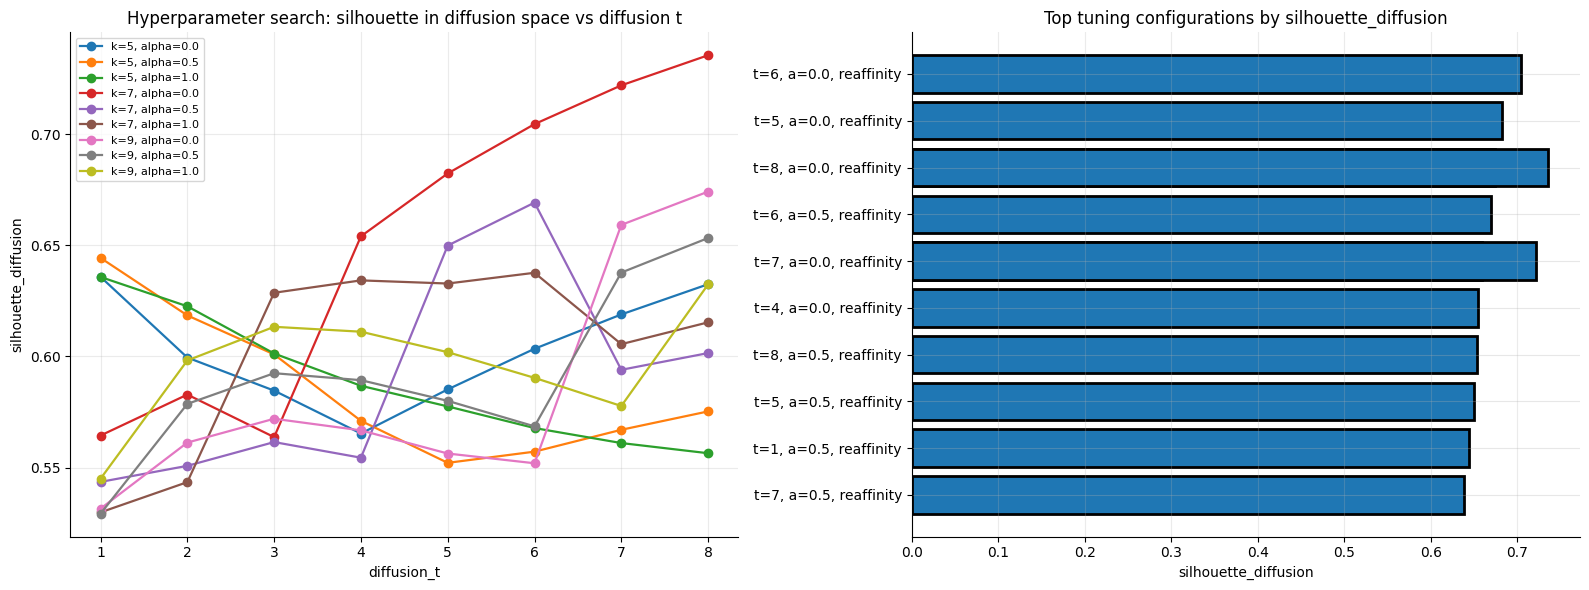

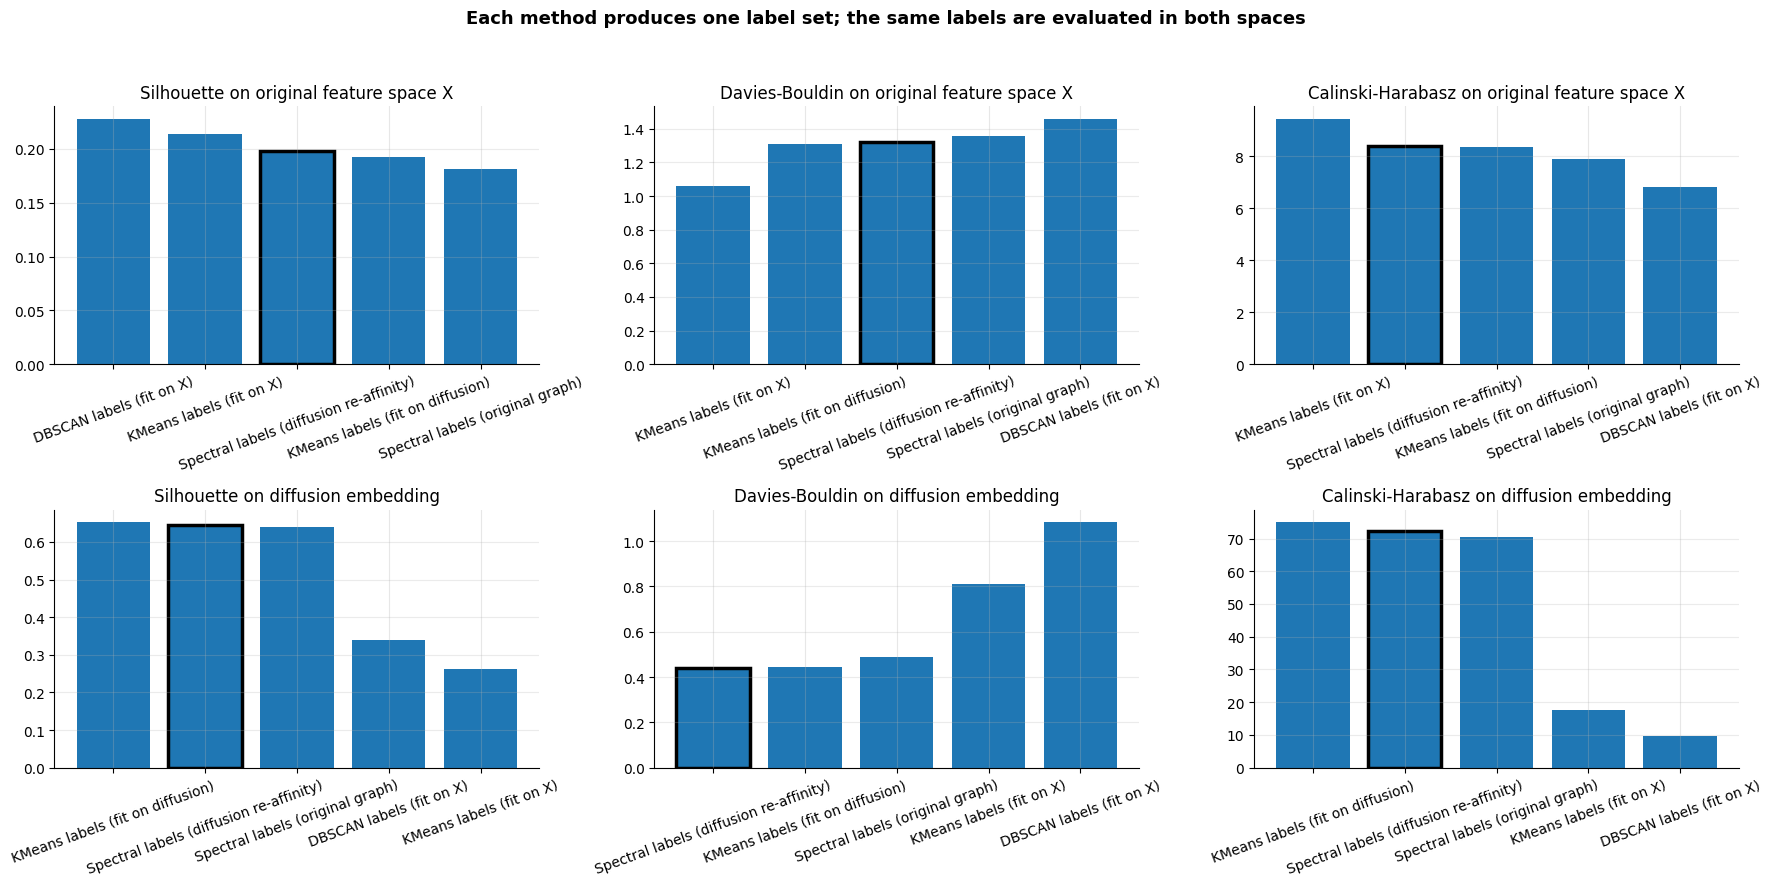

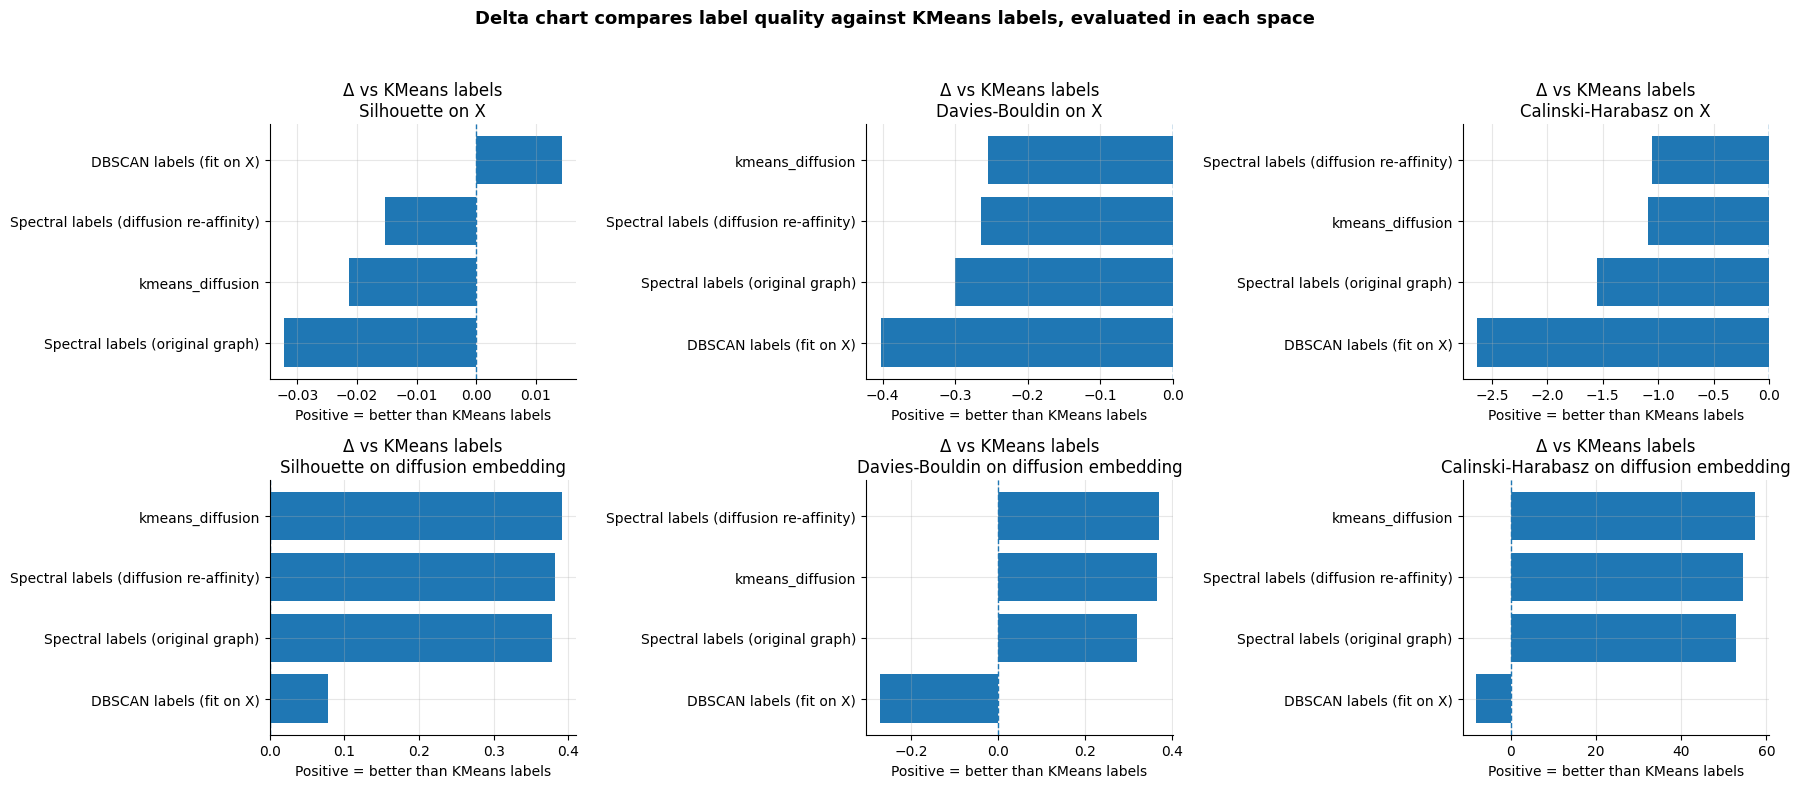

,method_pretty,Wins vs baseline,Total signed advantage,Silhouette on X,Davies-Bouldin on X,Calinski-Harabasz on X,Silhouette on diffusion embedding,Davies-Bouldin on diffusion embedding,Calinski-Harabasz on diffusion embedding
0,kmeans_diffusion,3,56.729172,-0.021352,-0.254389,-1.089254,0.390909,0.366927,57.336330
1,Spectral labels (diffusion re-affinity),3,53.971138,-0.015239,-0.263830,-1.055073,0.382714,0.370220,54.552346
2,Spectral labels (original graph),3,51.602816,-0.032311,-0.300269,-1.553271,0.377994,0.321301,52.789373
3,DBSCAN labels (fit on X),2,-11.263665,0.014406,-0.402703,-2.634125,0.077662,-0.272421,-8.046483


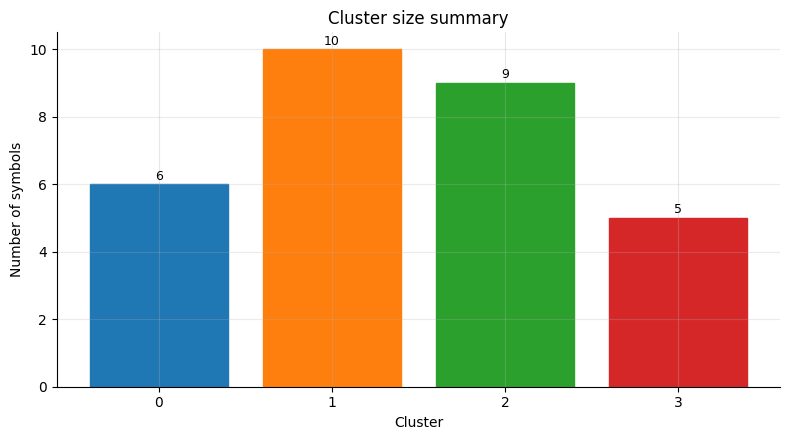

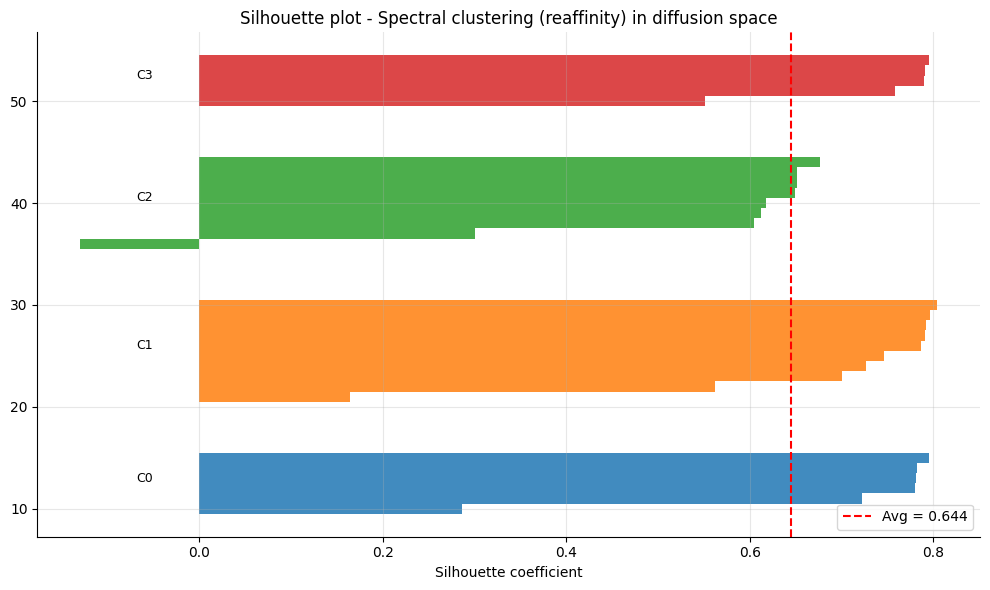

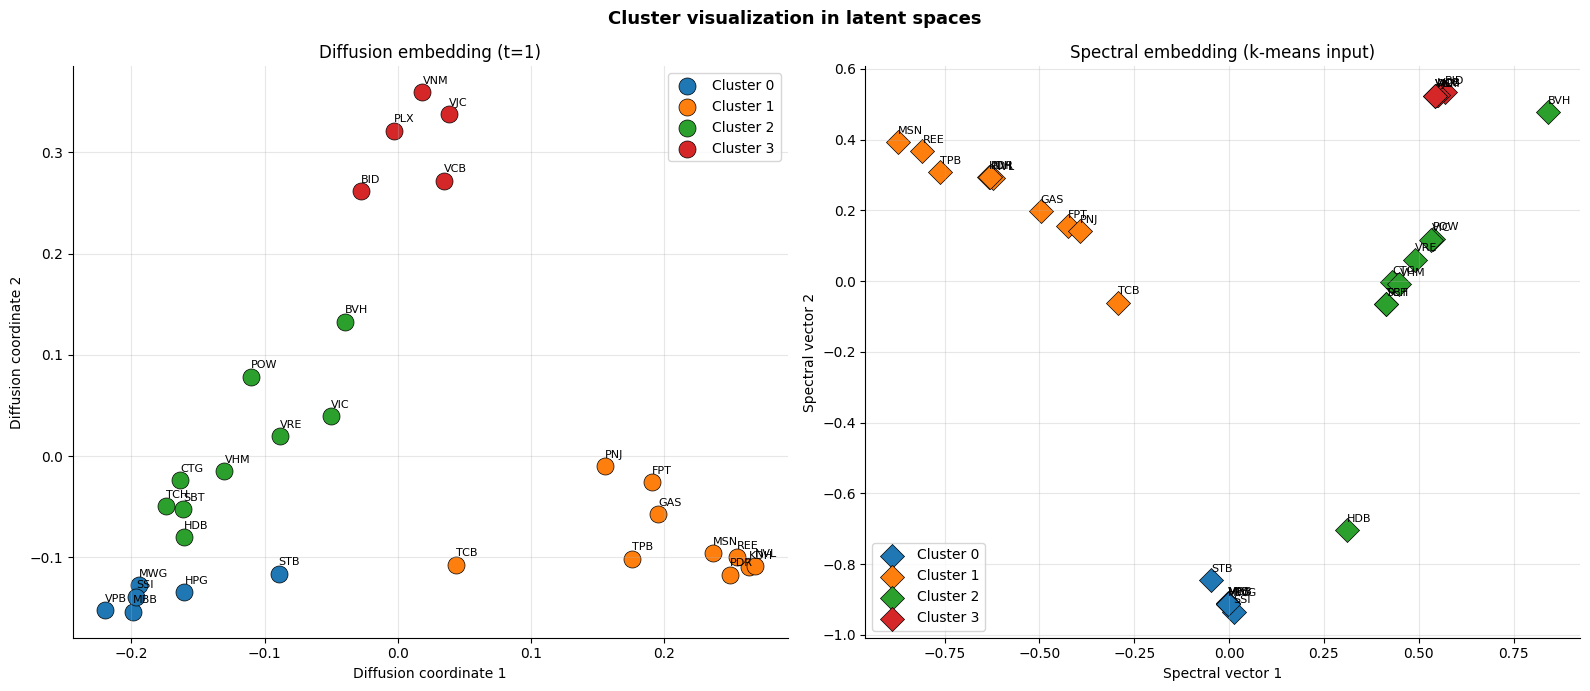

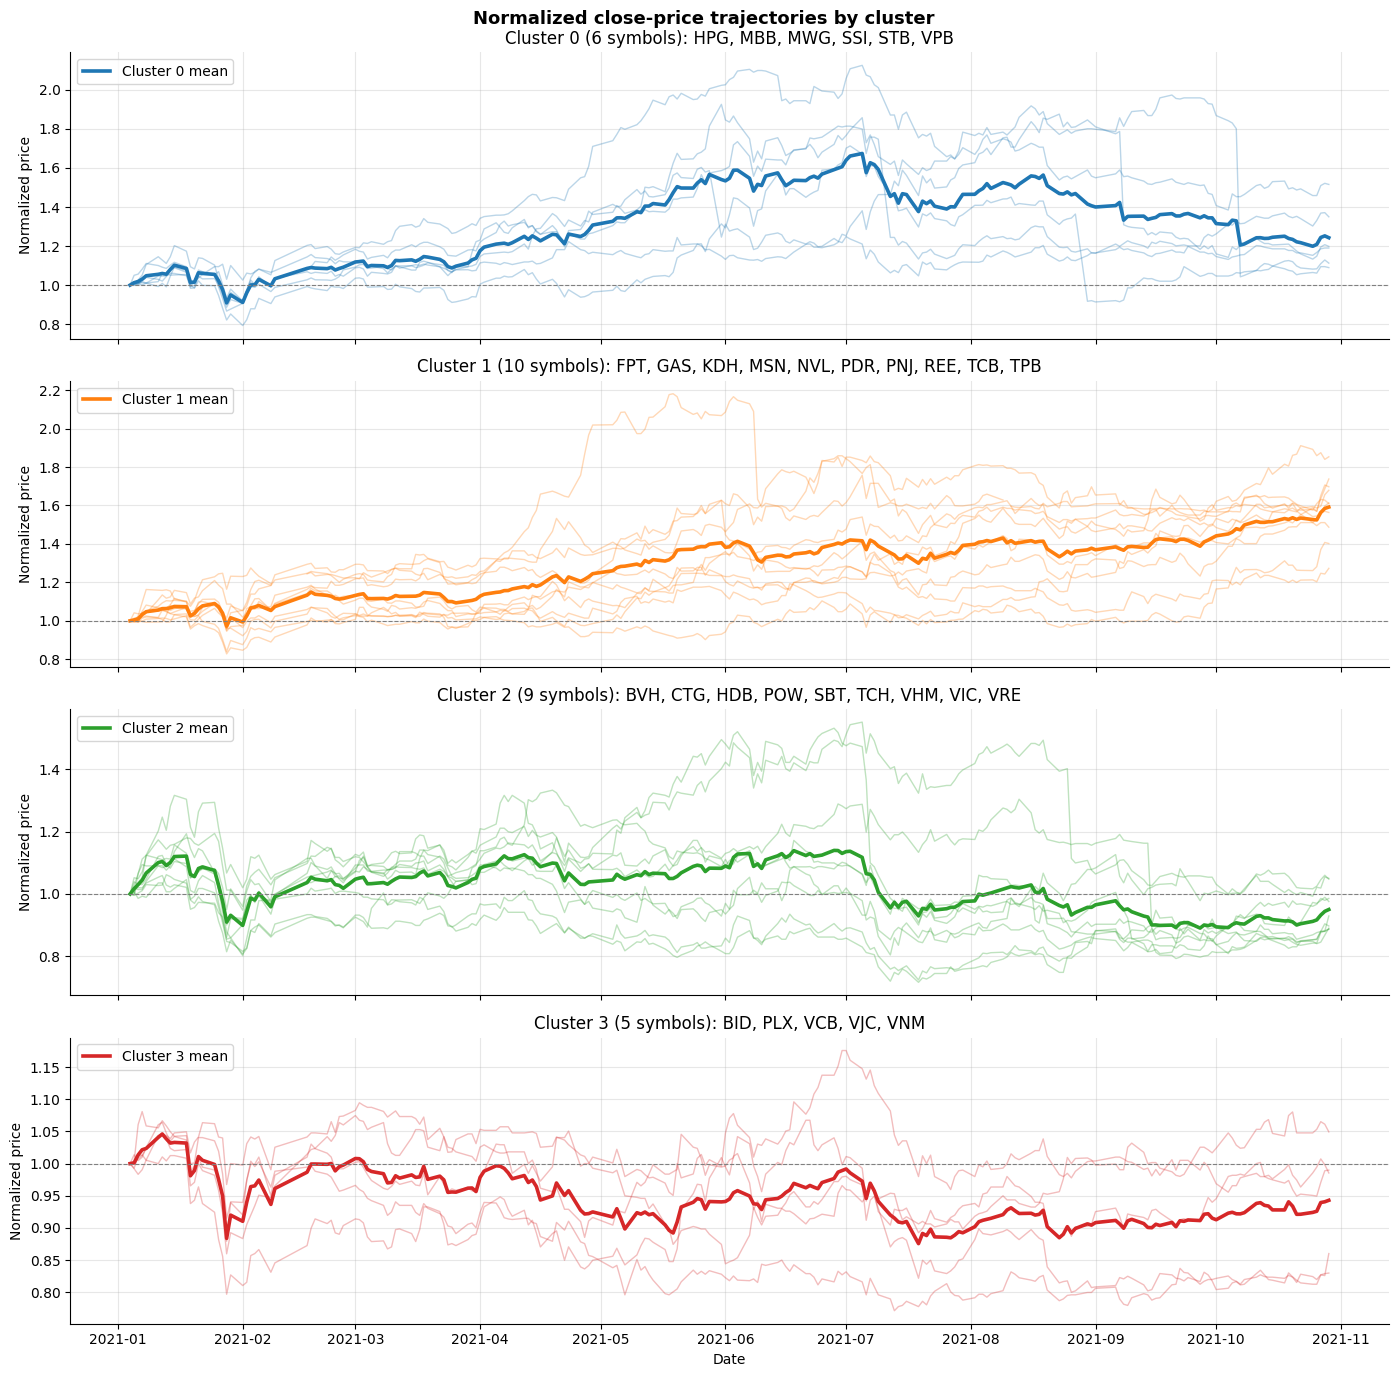

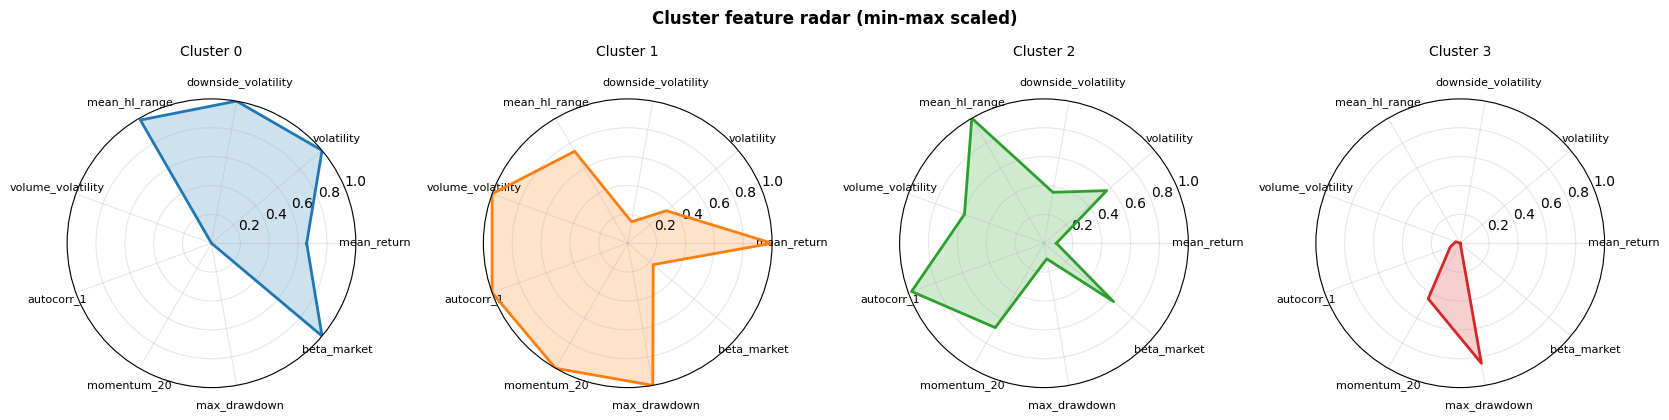

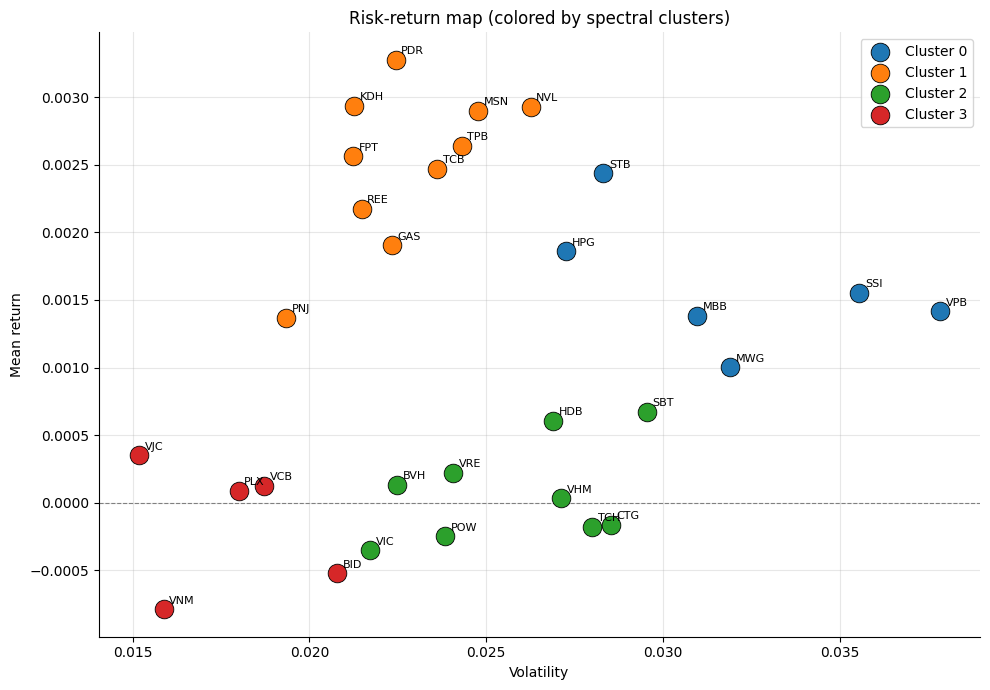


Global silhouette mean (diffusion space): 0.6444

Cluster quality summary:


,cluster,cluster_name,n_symbols,silhouette_mean,quality,members,mean_return,volatility,max_drawdown,beta_market,momentum_20
0,0,High-growth high-risk,6,0.6911,good,"HPG, MBB, MWG, SSI, STB, VPB",0.0016,0.0320,-0.3809,1.2658,-0.0243
1,1,Quality growth,10,0.6867,good,"FPT, GAS, KDH, MSN, NVL, PDR, PNJ, REE, TCB, TPB",0.0025,0.0227,-0.1876,0.8815,0.1065
2,2,High drawdown risk,9,0.5148,good,"BVH, CTG, HDB, POW, SBT, TCH, VHM, VIC, VRE",0.0001,0.0258,-0.3597,1.0806,0.0640
3,3,Defensive underperformer,5,0.7369,good,"BID, PLX, VCB, VJC, VNM",-0.0001,0.0177,-0.2176,0.7665,0.0337



Potential borderline / outlier stocks (low silhouette):


,symbol,cluster,silhouette,flag
0,HDB,2,-0.1295,outlier


Interpretation: `outlier` means silhouette < 0, `borderline` means low positive silhouette, and `lowest_silhouette` is a fallback list of the weakest-assigned stocks when no strict outlier exists.

Cluster profile (raw means):


,mean_return,volatility,downside_volatility,mean_hl_range,mean_oc_return,volume_volatility,autocorr_1,momentum_20,max_drawdown,beta_market
cluster,,,,,,,,,,
0,0.0016,0.0320,0.0327,0.0316,0.0021,0.5098,-0.0197,-0.0243,-0.3809,1.2658
1,0.0025,0.0227,0.0157,0.0296,0.0023,0.8444,0.0294,0.1065,-0.1876,0.8815
2,0.0001,0.0258,0.0199,0.0317,-0.0002,0.7059,0.0283,0.0640,-0.3597,1.0806
3,-0.0001,0.0177,0.0127,0.0236,-0.0005,0.5207,-0.0161,0.0337,-0.2176,0.7665



Cluster profile (z-score by feature across clusters):


,mean_return,volatility,downside_volatility,mean_hl_range,mean_oc_return,volume_volatility,autocorr_1,momentum_20,max_drawdown,beta_market
cluster,,,,,,,,,,
0,0.541,1.437,1.633,0.751,0.927,-0.975,-1.075,-1.455,-1.113,1.400
1,1.366,-0.356,-0.594,0.136,1.063,1.434,1.023,1.292,1.165,-0.614
2,-0.850,0.243,-0.050,0.787,-0.871,0.437,0.973,0.399,-0.863,0.430
3,-1.058,-1.323,-0.989,-1.673,-1.119,-0.896,-0.922,-0.236,0.811,-1.216


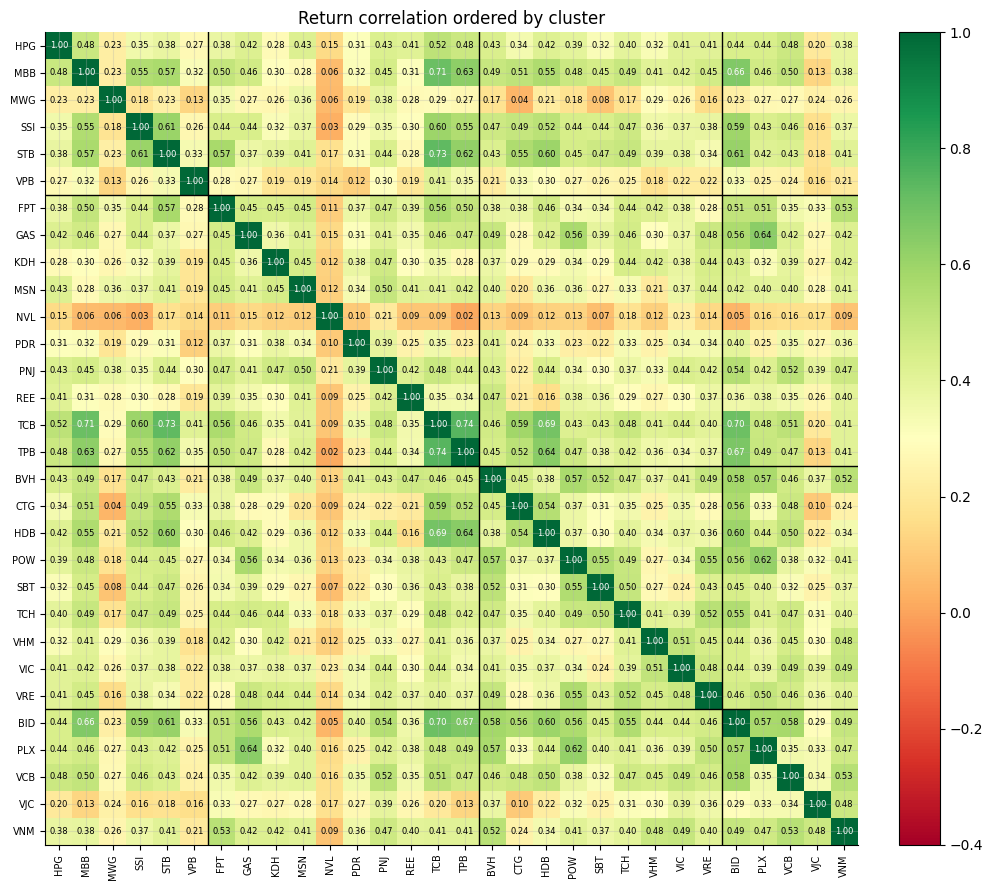


Cluster correlation stats:


,intra_mean_corr,inter_mean_corr,gap_intra_minus_inter
0,0.3763,0.367,0.0093


In [63]:
# =========================
# Execute optimized spectral diffusion pipeline + plots
# =========================

plt.rcParams.update(
    {
        "figure.figsize": (10, 6),
        "axes.grid": True,
        "grid.alpha": 0.3,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "font.size": 10,
    }
)

from IPython.display import Markdown

symbols = prep_artifacts["symbols"]

print("Pipeline:")
print(
    "Raw prices -> Feature Engineering -> self-tuning kNN graph -> "
    "alpha-normalized diffusion maps -> optional diffusion-space re-affinity -> "
    "spectral clustering"
)

# 1) Hyper-parameter tuning for spectral diffusion
auto_run, tuning_df = tune_spectral_hyperparams(
    X_scaled=X_scaled,
    symbols=symbols,
    k_neighbor_grid=(5, 7, 9),
    diffusion_t_grid=(1, 2, 3, 4, 5, 6, 7, 8),
    diffusion_alpha_grid=(0.0, 0.5, 1.0),
    cluster_k_grid=(2, 3, 4, 5, 6),
    local_t_radius=0,
    use_reaffinity=True,
)

tuning_display_cols = [
    "phase",
    "k_neighbors",
    "diffusion_alpha",
    "diffusion_t",
    "selected_variant",
    "best_k",
    "silhouette_diffusion",
    "davies_bouldin_diffusion",
]

print("\nTop tuning results:")
display(tuning_df[tuning_display_cols].round(4).head(12))

print("\nAuto-selected config from grid search:")
print(
    f"- k_neighbors         : {auto_run['k_neighbors']}\n"
    f"- diffusion_t         : {auto_run['diffusion_t']}\n"
    f"- diffusion_alpha     : {auto_run['diffusion_alpha']:.1f}\n"
    f"- selected_variant    : {auto_run['selected_variant']}\n"
    f"- best_k              : {auto_run['best_k']}\n"
    f"- silhouette_diffusion: {auto_run['final_silhouette_diffusion']:.4f}\n"
    f"- davies_bouldin_diff.: {auto_run['final_davies_bouldin_diffusion']:.4f}"
)

# 1b) Lock a more presentation-friendly config for the final demo
demo_config = {
    "k_neighbors": 5,
    "diffusion_alpha": 0.5,
    "diffusion_t": 1,
    "cluster_k_grid": (2, 3, 4, 5, 6),
    "use_reaffinity": True,
}
best_run = run_spectral_once(
    X_scaled=X_scaled,
    symbols=symbols,
    **demo_config,
)

print("\nFinal demo config used in this notebook:")
print(
    f"- k_neighbors         : {best_run['k_neighbors']}\n"
    f"- diffusion_t         : {best_run['diffusion_t']}\n"
    f"- diffusion_alpha     : {best_run['diffusion_alpha']:.1f}\n"
    f"- selected_variant    : {best_run['selected_variant']}\n"
    f"- best_k              : {best_run['best_k']}\n"
    f"- silhouette_diffusion: {best_run['final_silhouette_diffusion']:.4f}\n"
    f"- davies_bouldin_diff.: {best_run['final_davies_bouldin_diffusion']:.4f}"
)

display(
    Markdown(
        """
### Demo note

- The automatic search prefers a 2-cluster solution because it maximizes diffusion-space separation.
- For presentation, this notebook uses a fixed demo config: `k_neighbors=5`, `diffusion_alpha=0.5`, `diffusion_t=1`.
- This fixed config produces `4` clusters with a more interpretable size split, which is easier to explain in a demo.
- The main claim should be: diffusion space separates the stocks more clearly than KMeans on the same `k`.
- Do **not** claim that diffusion is better on every metric in the original feature space `X`, because `silhouette_X` is still slightly lower than KMeans.
- `KMeans labels (fit on diffusion)` is included as a non-spectral diffusion baseline: it uses diffusion coordinates directly, without rebuilding the graph.
        """
    )
)

print("\nK-search table under final demo config:")
display(best_run["k_search_table"].round(4))

# 2) Benchmark methods on same dataset
base_labels = None
reaff_labels = None
if "base" in best_run["variant_runs"]:
    base_labels = best_run["variant_runs"]["base"]["labels"]
if "reaffinity" in best_run["variant_runs"]:
    reaff_labels = best_run["variant_runs"]["reaffinity"]["labels"]

metrics_df, labels_by_method, benchmark_meta = compare_clustering_methods(
    X_scaled=X_scaled,
    diffusion_embedding=best_run["diffusion_embedding"],
    best_k=best_run["best_k"],
    spectral_base_labels=base_labels,
    spectral_reaffinity_labels=reaff_labels,
)

metric_display_cols = [
    "method_pretty",
    "n_clusters_found",
    "has_noise",
    "silhouette_X",
    "silhouette_diffusion",
    "davies_bouldin_X",
    "davies_bouldin_diffusion",
    "calinski_harabasz_X",
    "calinski_harabasz_diffusion",
]

print("\nMethod comparison (same labels evaluated in both spaces):")
display(metrics_df[metric_display_cols].round(4))
print(
    "\nInterpretation note: each method creates one set of cluster labels. "
    "Those same labels are then evaluated twice: once on original feature space X, "
    "and once on the diffusion embedding."
)
print(
    "For this demo, the preferred reading is the diffusion-space comparison: "
    "the re-affinity variant creates visibly cleaner separation in latent space, "
    "even though X-space metrics are not universally better."
)
print(
    "Also compare against 'KMeans labels (fit on diffusion)' to isolate the effect of "
    "diffusion coordinates alone, without the extra re-affinity step."
)

variant_to_method = {
    "base": "spectral_base",
    "reaffinity": "spectral_reaffinity",
}
final_method = variant_to_method.get(best_run["selected_variant"], "spectral_base")

advantage_df = summarize_proposed_method_advantage(
    metrics_df=metrics_df,
    proposed_method=final_method,
)
if not advantage_df.empty:
    print(f"\nWhere the selected method ({METHOD_NAME_MAP.get(final_method, final_method)}) is better / worse:")
    display(advantage_df.round(4))

if final_method != "spectral_reaffinity":
    print(
        "\nNote: the tuned search did not choose re-affinity. "
        f"The selected method is {METHOD_NAME_MAP.get(final_method, final_method)}, "
        "so any comparison should use that as the final spectral result."
    )

print(
    f"DBSCAN config (auto-selected): eps={benchmark_meta['dbscan_eps']:.4f}, "
    f"min_samples={benchmark_meta['dbscan_min_samples']}"
)

# 3) Final labels = selected spectral variant
final_labels = labels_by_method[final_method]

cluster_output_df = feature_imputed_df.copy()
cluster_output_df["cluster"] = final_labels

cluster_membership = pd.DataFrame(
    {
        "symbol": symbols,
        "cluster": final_labels,
    }
).sort_values(["cluster", "symbol"]).reset_index(drop=True)

cluster_size_df = (
    cluster_membership["cluster"]
    .value_counts()
    .sort_index()
    .rename("n_symbols")
    .to_frame()
)

print(f"\nFinal clustering method used: {METHOD_NAME_MAP.get(final_method, final_method)}")
print("\nCluster membership:")
display(cluster_membership)

print("\nCluster sizes:")
display(cluster_size_df)

# 4) Show key outputs on screen only
run_summary_df = pd.DataFrame(
    [
        {
            "selected_variant": best_run["selected_variant"],
            "k_neighbors": best_run["k_neighbors"],
            "diffusion_t": best_run["diffusion_t"],
            "diffusion_alpha": best_run["diffusion_alpha"],
            "best_k": best_run["best_k"],
            "silhouette_diffusion": best_run["final_silhouette_diffusion"],
            "davies_bouldin_diffusion": best_run["final_davies_bouldin_diffusion"],
        }
    ]
)

print("\nSelected run summary:")
display(run_summary_df.round(4))

print("\nCSV export disabled: results are displayed in the notebook only.")

# 5) Plots
plot_tuning_search_overview(tuning_df)
plot_method_metrics(metrics_df, proposed_method=final_method)
baseline_delta_df = plot_vs_kmeans_baseline(
    metrics_df,
    baseline_method="kmeans_features",
)
plot_cluster_size_summary(cluster_size_df)

plot_silhouette_chart(
    X_eval=best_run["diffusion_embedding"],
    labels=final_labels,
    title=f"Silhouette plot - Spectral clustering ({best_run['selected_variant']}) in diffusion space",
)

plot_cluster_embeddings(
    diffusion_embedding=best_run["diffusion_embedding"],
    U_norm=best_run["U_norm"],
    labels=final_labels,
    symbols=symbols,
    diffusion_t=best_run["diffusion_t"],
)

plot_cluster_price_trajectories(
    norm_price_wide=norm_price_wide,
    labels=final_labels,
    symbols=symbols,
)

plot_cluster_radar(
    feature_df_plot=feature_imputed_df,
    labels=final_labels,
)

plot_risk_return_map(
    feature_df_plot=feature_imputed_df,
    labels=final_labels,
    symbols=symbols,
)

# 6) Full interpretation block
sil_values, sil_avg = compute_silhouette_values(
    X_eval=best_run["diffusion_embedding"],
    labels=final_labels,
)
print(f"\nGlobal silhouette mean (diffusion space): {sil_avg:.4f}")

cluster_profile, cluster_profile_z = build_cluster_profile(
    feature_df_plot=feature_imputed_df,
    labels=final_labels,
)

cluster_quality_df = summarize_cluster_quality(
    symbols=symbols,
    labels=final_labels,
    sil_values=sil_values,
    cluster_profile=cluster_profile,
)

print("\nCluster quality summary:")
display(cluster_quality_df.round(4))

outlier_df = detect_silhouette_outliers(
    symbols=symbols,
    labels=final_labels,
    sil_values=sil_values,
    threshold=0.10,
    top_n_if_empty=8,
)

print("\nPotential borderline / outlier stocks (low silhouette):")
display(outlier_df.round(4))
print(
    "Interpretation: `outlier` means silhouette < 0, `borderline` means low positive silhouette, "
    "and `lowest_silhouette` is a fallback list of the weakest-assigned stocks when no strict outlier exists."
)

print("\nCluster profile (raw means):")
display(cluster_profile.round(4))

print("\nCluster profile (z-score by feature across clusters):")
display(cluster_profile_z.round(3))

corr_df, corr_stats = plot_cluster_correlation_heatmap(
    ret_wide=ret_wide,
    labels=final_labels,
    symbols=symbols,
)

print("\nCluster correlation stats:")
display(pd.DataFrame([corr_stats]).round(4))


In [64]:

# =========================
# Optional demo: train on 29 symbols, assign cluster for 1 holdout symbol
# =========================

from scipy.optimize import linear_sum_assignment
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans


def align_cluster_labels_by_reference(
    predicted_train_labels: np.ndarray,
    reference_train_labels: np.ndarray,
) -> dict:
    """
    Align cluster IDs from a predicted partition to a reference partition
    using Hungarian matching on the training symbols only.
    """
    pred_s = pd.Series(predicted_train_labels, name="pred")
    ref_s = pd.Series(reference_train_labels, name="ref")

    ct = pd.crosstab(pred_s, ref_s)
    if ct.empty:
        return {}

    r, c = linear_sum_assignment(-ct.values)
    return {ct.index[i]: ct.columns[j] for i, j in zip(r, c)}


def fit_train_predict_one(
    feature_df: pd.DataFrame,
    holdout_symbol: str,
    n_clusters: int,
    k_neighbors: int,
    random_state: int = 42,
    reference_full_labels: pd.Series | None = None,
) -> dict:
    """
    Train spectral clustering on all symbols except holdout_symbol,
    then assign holdout_symbol to one learned cluster via Nystrom extension.

    Notes
    -----
    - This holdout demo is kept on the base spectral graph for simplicity.
    - If reference_full_labels is provided, the predicted cluster ID is aligned
      to the full-run labeling by Hungarian matching on the train symbols.
    """
    if holdout_symbol not in feature_df.index:
        raise ValueError(f"holdout_symbol '{holdout_symbol}' not found in feature_df index.")

    if len(feature_df) < 6:
        raise ValueError("Need at least 6 symbols for a stable holdout demo.")

    train_df = feature_df.drop(index=holdout_symbol).copy()
    test_df = feature_df.loc[[holdout_symbol]].copy()

    # Fit preprocessing on train only
    imputer = SimpleImputer(strategy="median")
    X_train_imp = imputer.fit_transform(train_df)
    X_test_imp = imputer.transform(test_df)

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train_imp)
    x_new = scaler.transform(X_test_imp)[0]

    train_symbols = train_df.index.tolist()

    # Build train graph and spectral basis
    W_train, _, graph_info_train = build_self_tuning_knn_affinity(
        X_scaled=X_train,
        symbols=train_symbols,
        k_neighbors=k_neighbors,
    )
    spec_train = compute_spectral_decomposition(W_train)

    k_use = int(max(2, min(n_clusters, len(train_symbols) - 1)))
    U_train = build_spectral_embedding(
        eigenvectors=spec_train["eigenvectors"],
        n_clusters=k_use,
        drop_first=True,
        row_normalize=True,
    )

    km = KMeans(n_clusters=k_use, random_state=random_state, n_init=100)
    train_labels = km.fit_predict(U_train)

    # Out-of-sample extension for one new node
    sigma_train = np.asarray(graph_info_train["sigma"], dtype=float)
    degree_train = np.asarray(spec_train["degree"], dtype=float)

    eps = 1e-12
    d_new = np.linalg.norm(X_train - x_new[None, :], axis=1)

    k_graph = int(graph_info_train["k_neighbors_used"])
    k_graph = max(1, min(k_graph, len(d_new)))

    sigma_new = float(np.partition(d_new, k_graph - 1)[k_graph - 1])
    sigma_new = max(sigma_new, eps)

    # self-tuning Gaussian affinity to train nodes
    w_new = np.exp(-(d_new ** 2) / np.maximum(sigma_new * sigma_train, eps))

    # keep only k nearest edges (consistent with kNN graph spirit)
    keep_idx = np.argsort(d_new)[:k_graph]
    mask = np.zeros_like(w_new, dtype=bool)
    mask[keep_idx] = True
    w_new = w_new * mask

    d_new_node = float(np.sum(w_new))
    if d_new_node <= eps:
        # safety fallback
        w_new = np.zeros_like(w_new)
        w_new[keep_idx] = np.exp(
            -(d_new[keep_idx] ** 2) / np.maximum(sigma_new * sigma_train[keep_idx], eps)
        )
        d_new_node = float(np.sum(w_new))

    s_new = w_new / np.sqrt(np.maximum(d_new_node, eps) * np.maximum(degree_train, eps))

    # Nystrom projection in spectral space of S = D^{-1/2} W D^{-1/2}
    eigvals_L = np.asarray(spec_train["eigenvalues"], dtype=float)
    eigvecs = np.asarray(spec_train["eigenvectors"], dtype=float)

    V = eigvecs[:, 1 : k_use + 1]  # non-trivial spectral vectors
    lambdas_S = 1.0 - eigvals_L[1 : k_use + 1]  # convert Laplacian eigenvalues to S eigenvalues
    lambdas_S = np.where(np.abs(lambdas_S) < eps, eps, lambdas_S)

    u_new = (s_new @ V) / lambdas_S
    u_new_norm = u_new / max(np.linalg.norm(u_new), eps)

    pred_cluster = int(km.predict(u_new_norm.reshape(1, -1))[0])

    # simple confidence proxy by nearest centroid distance
    centroid_dist = np.linalg.norm(km.cluster_centers_ - u_new_norm.reshape(1, -1), axis=1)
    confidence = float(1.0 / (1.0 + centroid_dist.min()))

    train_cluster_sizes = pd.Series(train_labels).value_counts().sort_index()

    result = {
        "holdout_symbol": holdout_symbol,
        "predicted_cluster": pred_cluster,
        "confidence_proxy": confidence,
        "k_neighbors": int(k_neighbors),
        "n_clusters": int(k_use),
        "train_cluster_sizes": train_cluster_sizes,
        "train_symbols": train_symbols,
        "train_labels": train_labels,
        "pred_cluster_raw": pred_cluster,
    }

    if reference_full_labels is not None:
        reference_train = reference_full_labels.loc[train_symbols].to_numpy()
        label_map = align_cluster_labels_by_reference(train_labels, reference_train)

        pred_cluster_mapped = label_map.get(pred_cluster, pred_cluster)
        full_label = int(reference_full_labels.loc[holdout_symbol])

        result["label_map_to_reference"] = label_map
        result["predicted_cluster_mapped"] = int(pred_cluster_mapped)
        result["reference_full_label"] = full_label
        result["match_after_mapping"] = bool(pred_cluster_mapped == full_label)

    return result


# ---- run demo ----
HOLDOUT_SYMBOL = "BID"
reference_full_labels = None
if "cluster_membership" in globals():
    reference_full_labels = cluster_membership.set_index("symbol")["cluster"]

demo_result = fit_train_predict_one(
    feature_df=feature_df,
    holdout_symbol=HOLDOUT_SYMBOL,
    n_clusters=int(best_run["best_k"]),
    k_neighbors=int(best_run["k_neighbors"]),
    random_state=RANDOM_STATE,
    reference_full_labels=reference_full_labels,
)

train_symbols = demo_result["train_symbols"]
train_labels = demo_result["train_labels"]
pred_cluster = demo_result["pred_cluster_raw"]
holdout_symbol = demo_result["holdout_symbol"]

print("Holdout assignment result:")
print(f"- holdout_symbol        : {demo_result['holdout_symbol']}")
print(f"- predicted_cluster_raw : {demo_result['predicted_cluster']}")
print(f"- confidence_proxy      : {demo_result['confidence_proxy']:.4f}")
print(f"- n_clusters(train)     : {demo_result['n_clusters']}")
print(f"- k_neighbors(train)    : {demo_result['k_neighbors']}")

print("\nTrain cluster sizes (29 symbols):")
display(demo_result["train_cluster_sizes"].rename("n_symbols").to_frame())

if "predicted_cluster_mapped" in demo_result:
    print("\nAligned-to-full-run comparison:")
    print(f"- predicted_cluster_mapped : {demo_result['predicted_cluster_mapped']}")
    print(f"- full_label               : {demo_result['reference_full_label']}")
    print(f"- match_after_mapping      : {demo_result['match_after_mapping']}")
    print(f"- label_map               : {demo_result['label_map_to_reference']}")


Holdout assignment result:
- holdout_symbol        : BID
- predicted_cluster_raw : 2
- confidence_proxy      : 0.5828
- n_clusters(train)     : 4
- k_neighbors(train)    : 5

Train cluster sizes (29 symbols):


,n_symbols
0,8
1,9
2,4
3,8



Aligned-to-full-run comparison:
- predicted_cluster_mapped : 3
- full_label               : 3
- match_after_mapping      : True
- label_map               : {np.int32(0): np.int32(0), np.int32(1): np.int32(1), np.int32(2): np.int32(3), np.int32(3): np.int32(2)}


In [65]:

# Label alignment has been integrated into the holdout demo cell above.
# No extra post-processing cell is needed anymore.
